# Análisis exploratorio de los datos

## Librerías

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

## Carga de datos

In [3]:
df_train = pd.read_csv("../data/conjuntos/datos_entrenamiento.csv")
df_test = pd.read_csv("../data/conjuntos/datos_prueba.csv")

df = pd.concat([df_train, df_test], ignore_index=True)
print(f"Filas totales: {len(df)}")

Filas totales: 15580


## Análisis
### Estadísticos básicos
Analizamos los estadísticos básicos

In [4]:
columnas_estadisticos = ["Voltaje", "Corriente", "Potencia", "FactorPotencia", "Frecuencia"]
df[columnas_estadisticos].describe()

,Voltaje,Corriente,Potencia,FactorPotencia,Frecuencia
count,15580.000000,15580.000000,15580.000000,15580.000000,15580.000000
mean,117.838188,2.637078,267.837521,0.787994,59.957718
std,2.636585,1.904476,220.767556,0.129881,0.017227
min,106.830000,0.328000,19.080000,0.461000,59.900000
25%,116.070000,1.642000,126.910000,0.723000,59.950000
50%,118.070000,2.278500,223.570000,0.832000,59.960000
75%,119.810000,3.213000,330.380000,0.866000,59.970000
max,124.760000,17.272000,1932.830000,1.000000,60.000000


Determinamos si existen valores atípicos utilizando el método del rango intercuartílico para identificar estadísticamente

In [5]:
def detectar_atipicos_iqr(df, columnas=[], factor=1.5):
    """
    Detecta valores atípicos usando el método del rango intercuartílico (IQR).
    Retorna un resumen por columna y una máscara booleana por fila.
    """

    resumen = []

    for col in columnas:
        serie = df[col].dropna()

        q1 = serie.quantile(0.25)
        q3 = serie.quantile(0.75)
        iqr = q3 - q1
        limite_inferior = q1 - factor * iqr
        limite_superior = q3 + factor * iqr

        mascara_col = (df[col] < limite_inferior) | (df[col] > limite_superior)
        n_atipicos = int(mascara_col.sum())
        pct_atipicos = (n_atipicos / len(df)) * 100 if len(df) else 0.0

        resumen.append({
            "columna": col,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "limite_inferior": limite_inferior,
            "limite_superior": limite_superior,
            "n_atipicos": n_atipicos,
            "pct_atipicos": round(pct_atipicos, 2),
        })

    resumen_df = pd.DataFrame(resumen).sort_values("n_atipicos", ascending=False).reset_index(drop=True)
    return resumen_df

Aplicamos la función y calculamos los valores atípicos

In [6]:
resumen_train = detectar_atipicos_iqr(df_train, columnas=columnas_estadisticos)
resumen_test = detectar_atipicos_iqr(df_test, columnas=columnas_estadisticos)
resumen_total = detectar_atipicos_iqr(df, columnas=columnas_estadisticos)

print("Atípicos en entrenamiento:")
display(resumen_train)

print("Atípicos en prueba:")
display(resumen_test)

print("Atípicos en dataset completo:")
display(resumen_total)

Atípicos en entrenamiento:


,columna,q1,q3,iqr,limite_inferior,limite_superior,n_atipicos,pct_atipicos
0,Corriente,1.6420,3.213,1.5710,-0.71450,5.56950,575,7.38
1,Potencia,126.9175,330.371,203.4535,-178.26275,635.55125,538,6.91
2,FactorPotencia,0.7230,0.866,0.1430,0.50850,1.08050,497,6.38
3,Frecuencia,59.9500,59.970,0.0200,59.92000,60.00000,283,3.63
4,Voltaje,116.0700,119.810,3.7400,110.46000,125.42000,42,0.54


Atípicos en prueba:


,columna,q1,q3,iqr,limite_inferior,limite_superior,n_atipicos,pct_atipicos
0,Corriente,1.6420,3.213,1.5710,-0.71450,5.56950,575,7.38
1,Potencia,126.9175,330.371,203.4535,-178.26275,635.55125,538,6.91
2,FactorPotencia,0.7230,0.866,0.1430,0.50850,1.08050,497,6.38
3,Frecuencia,59.9500,59.970,0.0200,59.92000,60.00000,283,3.63
4,Voltaje,116.0700,119.810,3.7400,110.46000,125.42000,42,0.54


Atípicos en dataset completo:


,columna,q1,q3,iqr,limite_inferior,limite_superior,n_atipicos,pct_atipicos
0,Corriente,1.642,3.213,1.571,-0.7145,5.5695,1150,7.38
1,Potencia,126.910,330.380,203.470,-178.2950,635.5850,1076,6.91
2,FactorPotencia,0.723,0.866,0.143,0.5085,1.0805,994,6.38
3,Frecuencia,59.950,59.970,0.020,59.9200,60.0000,566,3.63
4,Voltaje,116.070,119.810,3.740,110.4600,125.4200,84,0.54


### Graficamos las series

Graficamos las dos series por separado

Gráficas de entrenamiento por fase:


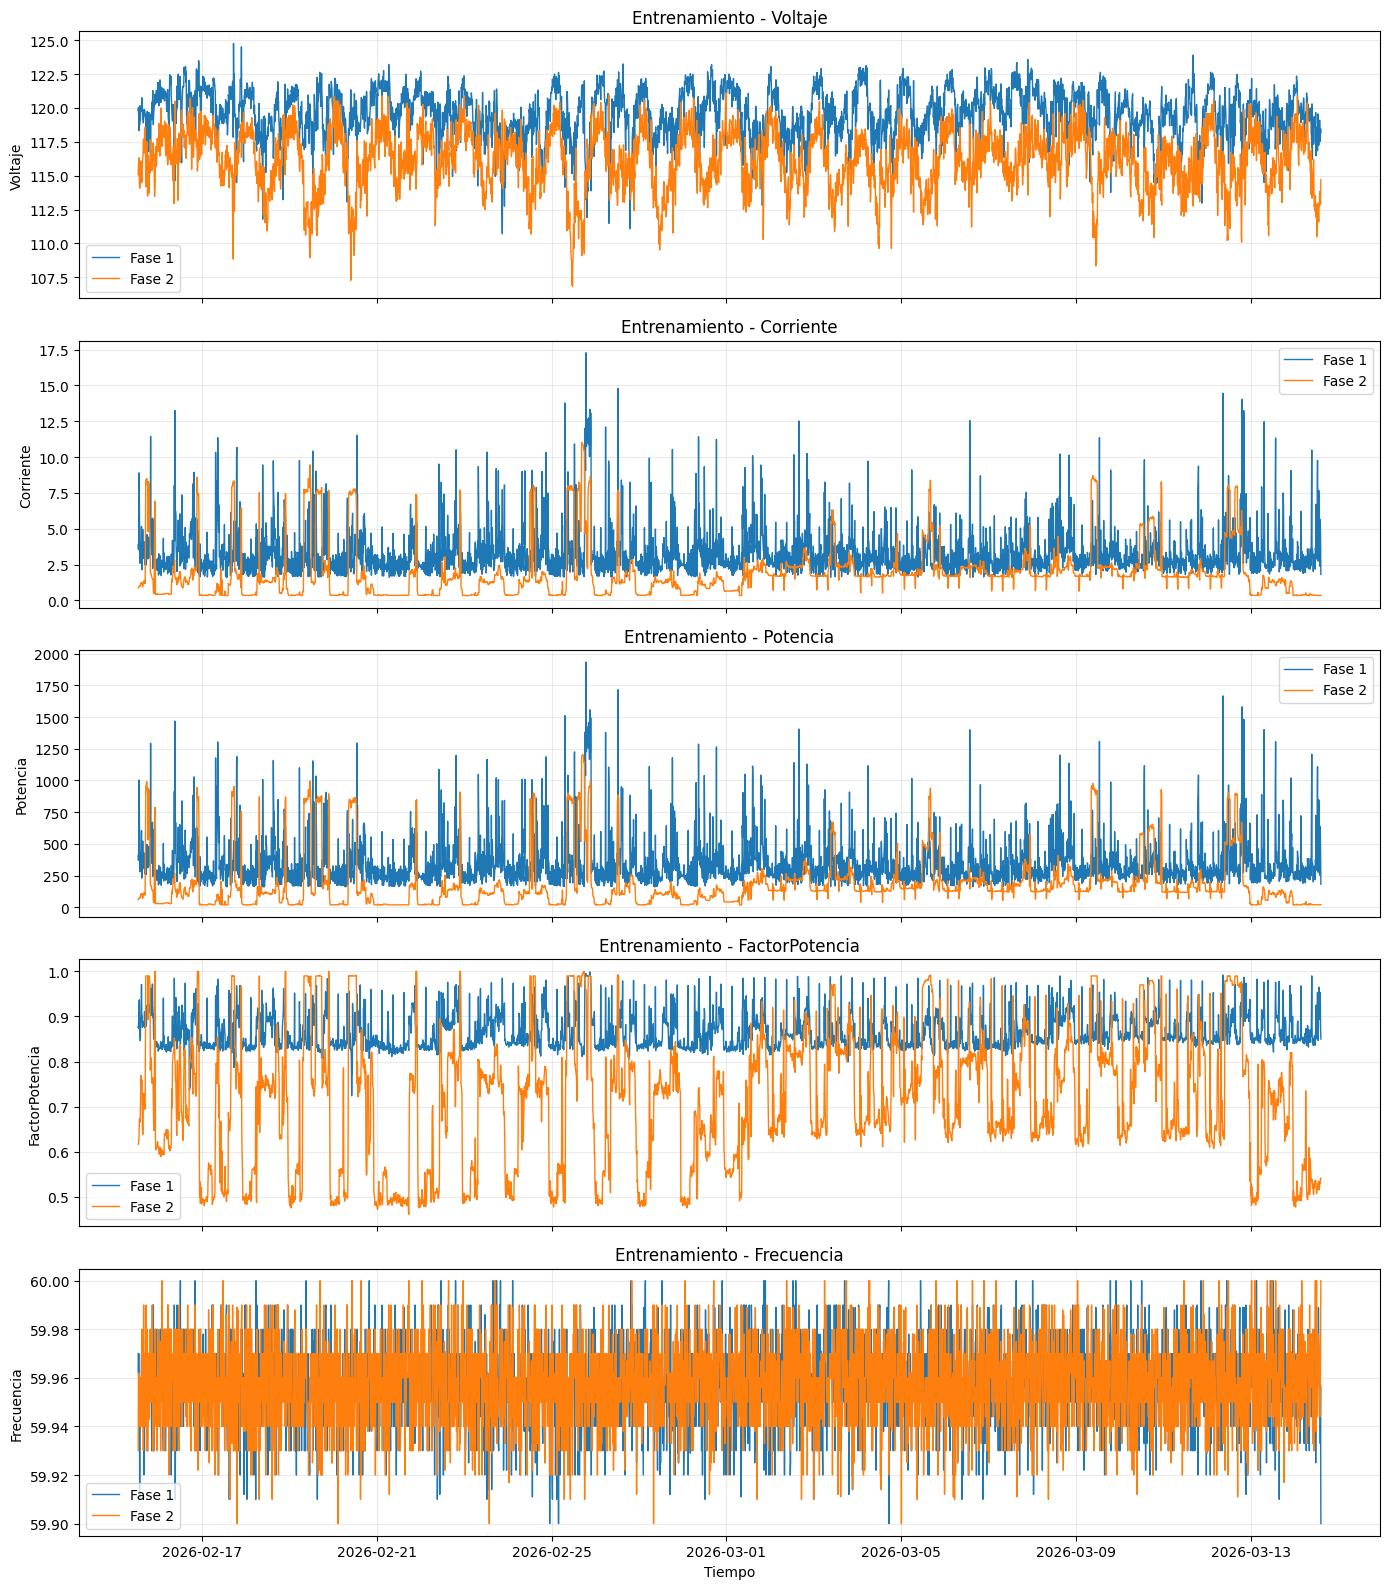

Gráficas de prueba por fase:


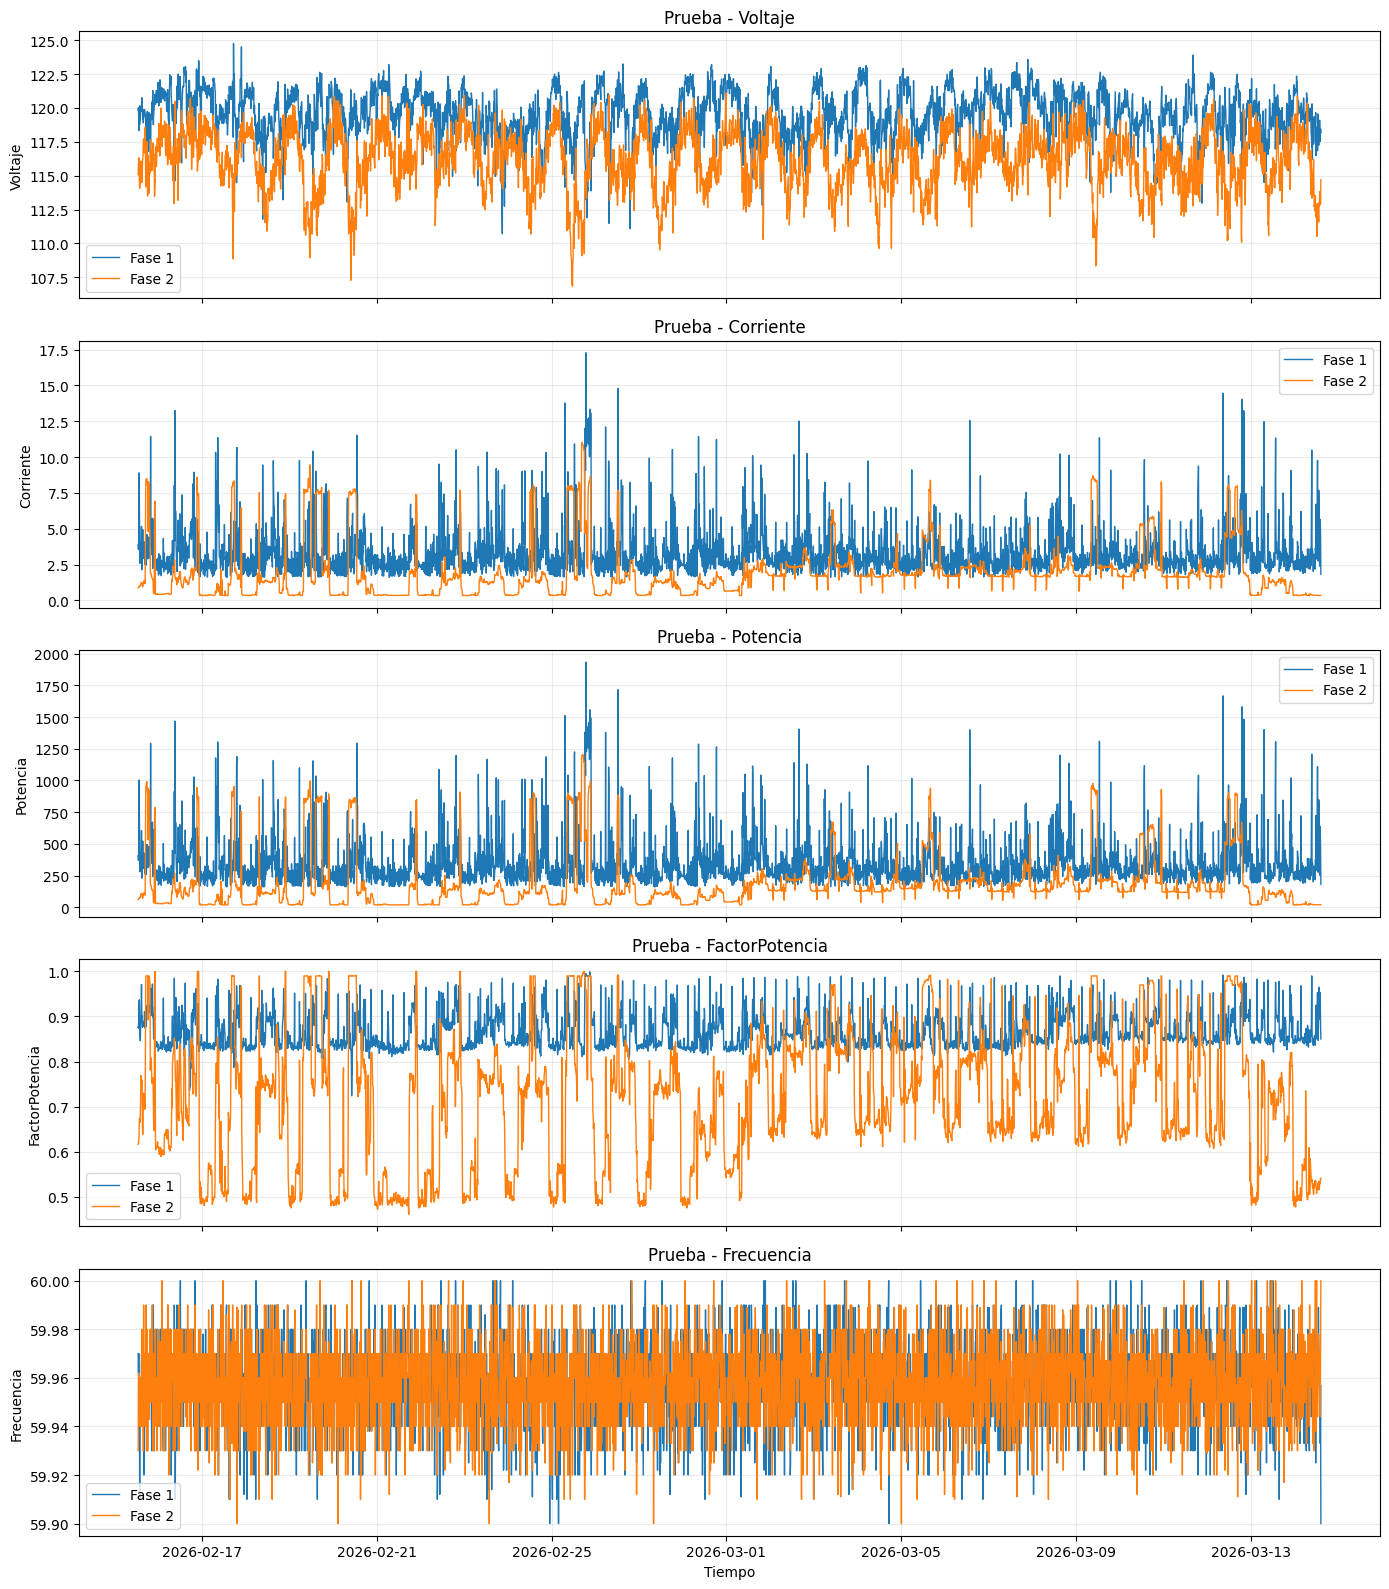

In [8]:
def graficar_series_por_fase(df_serie, nombre_serie, columnas, fases=(1, 2)):

    candidatos_fecha = ["FechaMedicion", "fecha", "datetime", "timestamp", "ds"]
    col_fecha = next((c for c in candidatos_fecha if c in df_serie.columns), None)
    col_fase = "Fase" if "Fase" in df_serie.columns else None

    data = df_serie.copy()


    if col_fecha is not None:
        data[col_fecha] = pd.to_datetime(data[col_fecha], errors="coerce")
        data = data.dropna(subset=[col_fecha]).sort_values(col_fecha)
        eje_x = col_fecha

    else:
        data = data.reset_index().rename(columns={"index": "idx"})
        eje_x = "idx"



    columnas_validas = [c for c in columnas if c in data.columns]
    if not columnas_validas:
        print(f"No hay columnas de columnas_analisis disponibles en {nombre_serie}.")
        return


    fig, axes = plt.subplots(
        nrows=len(columnas_validas),
        ncols=1,
        figsize=(14, 3.2 * len(columnas_validas)),
        sharex=True,
    )



    if len(columnas_validas) == 1:
        axes = [axes]

    colores = {1: "#1f77b4", 2: "#ff7f0e"}

    for ax, col in zip(axes, columnas_validas):

        if col_fase is not None:
            for fase in fases:
                data_fase = data[data[col_fase] == fase]
                if data_fase.empty:
                    continue

                ax.plot(
                    data_fase[eje_x],
                    data_fase[col],
                    linewidth=1.0,
                    color=colores.get(fase),
                    label=f"Fase {fase}",
                )

            ax.legend()

        else:
            ax.plot(data[eje_x], data[col], linewidth=1.0, color="#1f77b4", label=col)
            ax.legend()

        ax.set_title(f"{nombre_serie} - {col}")
        ax.set_ylabel(col)
        ax.grid(alpha=0.25)

    axes[-1].set_xlabel("Tiempo")
    plt.tight_layout()
    plt.show()

columnas_graficar = ["Voltaje", "Corriente", "Potencia", "FactorPotencia", "Frecuencia"]

print("Gráficas de entrenamiento por fase:")
graficar_series_por_fase(df_train, "Entrenamiento", columnas_graficar, fases=(1, 2))

print("Gráficas de prueba por fase:")
graficar_series_por_fase(df_test, "Prueba", columnas_graficar, fases=(1, 2))


### Distribución de las variables

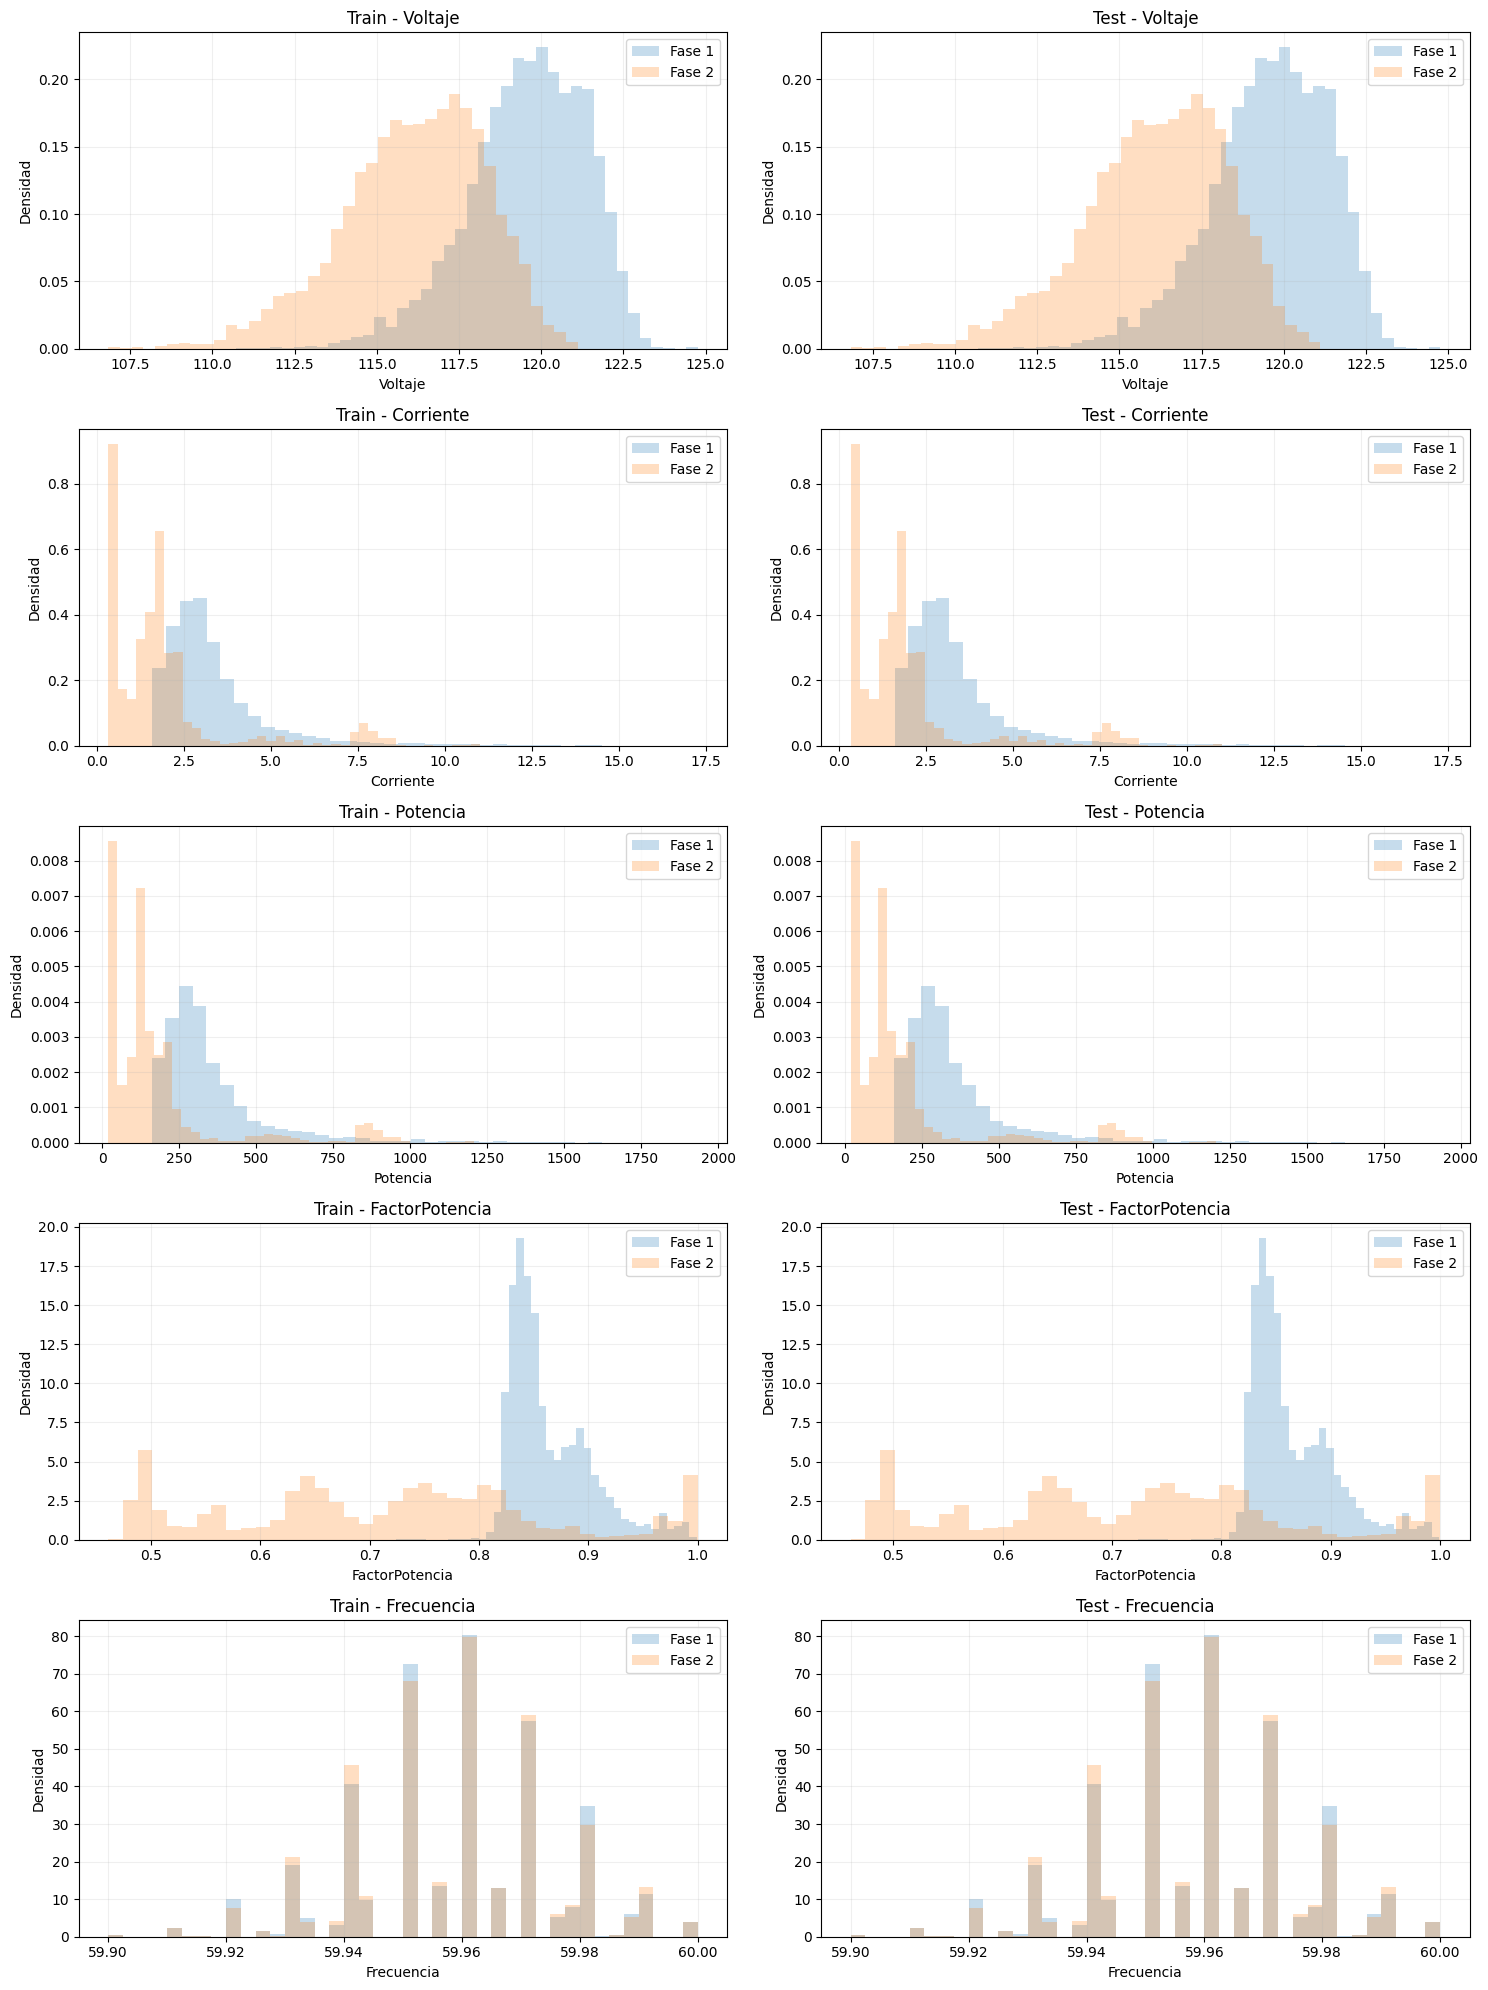

In [9]:
def graficar_distribucion_variables_por_fase(
    df_train, df_test, columnas, bins=40, fases=(1, 2)
):

    columnas_validas = [
        c for c in columnas if c in df_train.columns and c in df_test.columns
    ]

    if not columnas_validas:
        print("No hay columnas válidas para graficar en train y test.")
        return

    if "Fase" not in df_train.columns or "Fase" not in df_test.columns:
        print("No se encontró la columna 'Fase' en train y/o test.")
        return

    n = len(columnas_validas)
    ncols = 2  # izquierda: Train, derecha: Test
    nrows = n

    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols, figsize=(15, 4 * nrows), squeeze=False
    )

    colores = {1: "#1f77b4", 2: "#ff7f0e"}

    for i, col in enumerate(columnas_validas):
        ax_train = axes[i, 0]
        ax_test = axes[i, 1]

        # Train por fase
        for fase in fases:
            vals = df_train.loc[df_train["Fase"] == fase, col].dropna()
            if vals.empty:
                continue

            ax_train.hist(
                vals,
                bins=bins,
                alpha=0.25,
                density=True,
                label=f"Fase {fase}",
                color=colores.get(fase),
            )

        ax_train.set_title(f"Train - {col}")
        ax_train.set_xlabel(col)
        ax_train.set_ylabel("Densidad")
        ax_train.grid(alpha=0.2)
        ax_train.legend()

        # Test por fase

        for fase in fases:

            vals = df_test.loc[df_test["Fase"] == fase, col].dropna()

            if vals.empty:
                continue

            ax_test.hist(
                vals,
                bins=bins,
                alpha=0.25,
                density=True,
                label=f"Fase {fase}",
                color=colores.get(fase),
            )

        ax_test.set_title(f"Test - {col}")
        ax_test.set_xlabel(col)
        ax_test.set_ylabel("Densidad")
        ax_test.grid(alpha=0.2)
        ax_test.legend()

    plt.tight_layout()
    plt.show()


graficar_distribucion_variables_por_fase(df_train, df_test, columnas_graficar)

Descomposición de la serie

Descomposición de Train - Fase 1


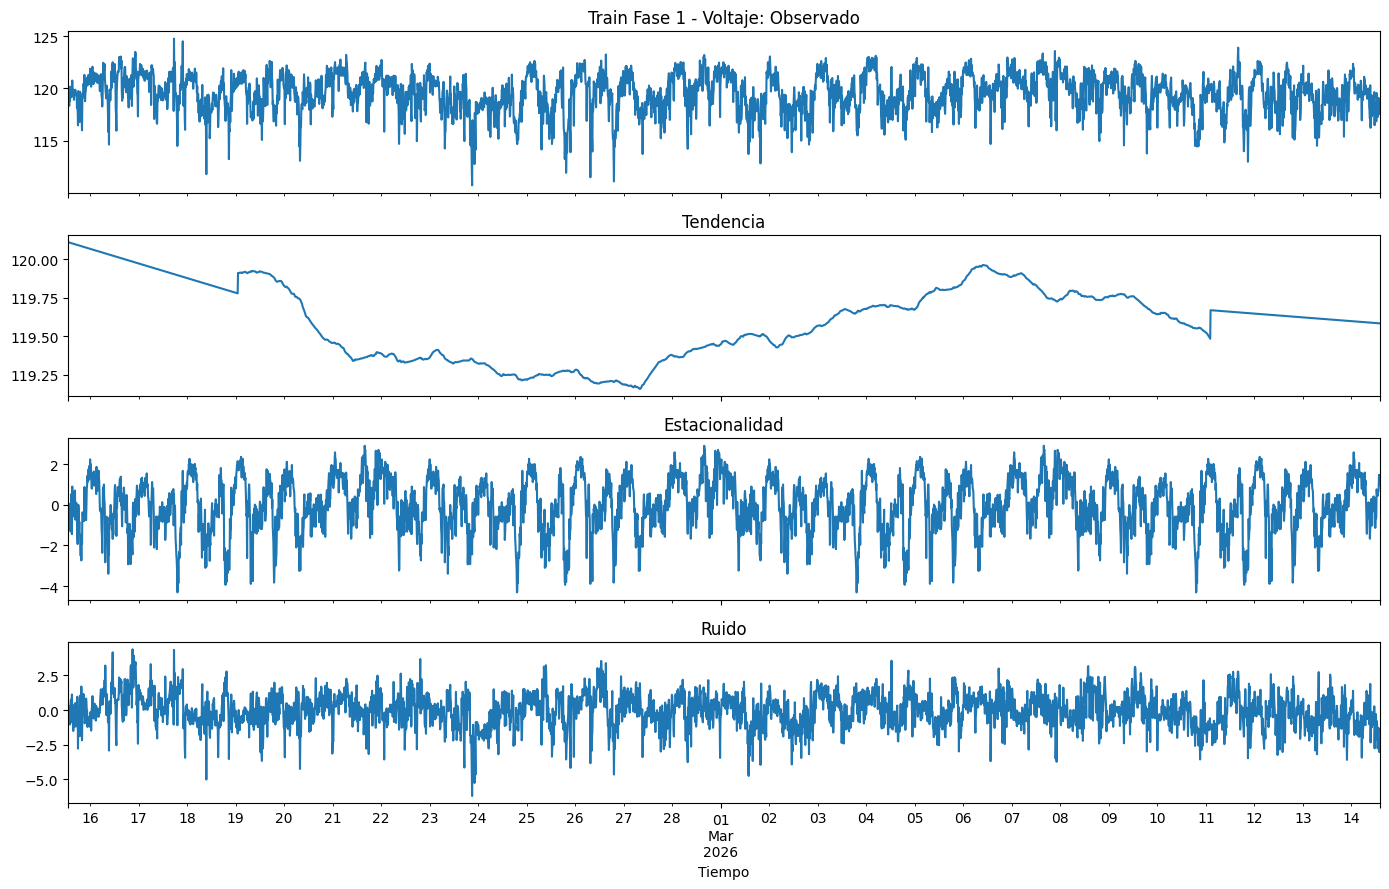

Descomposición completada: Train Fase 1 - Voltaje


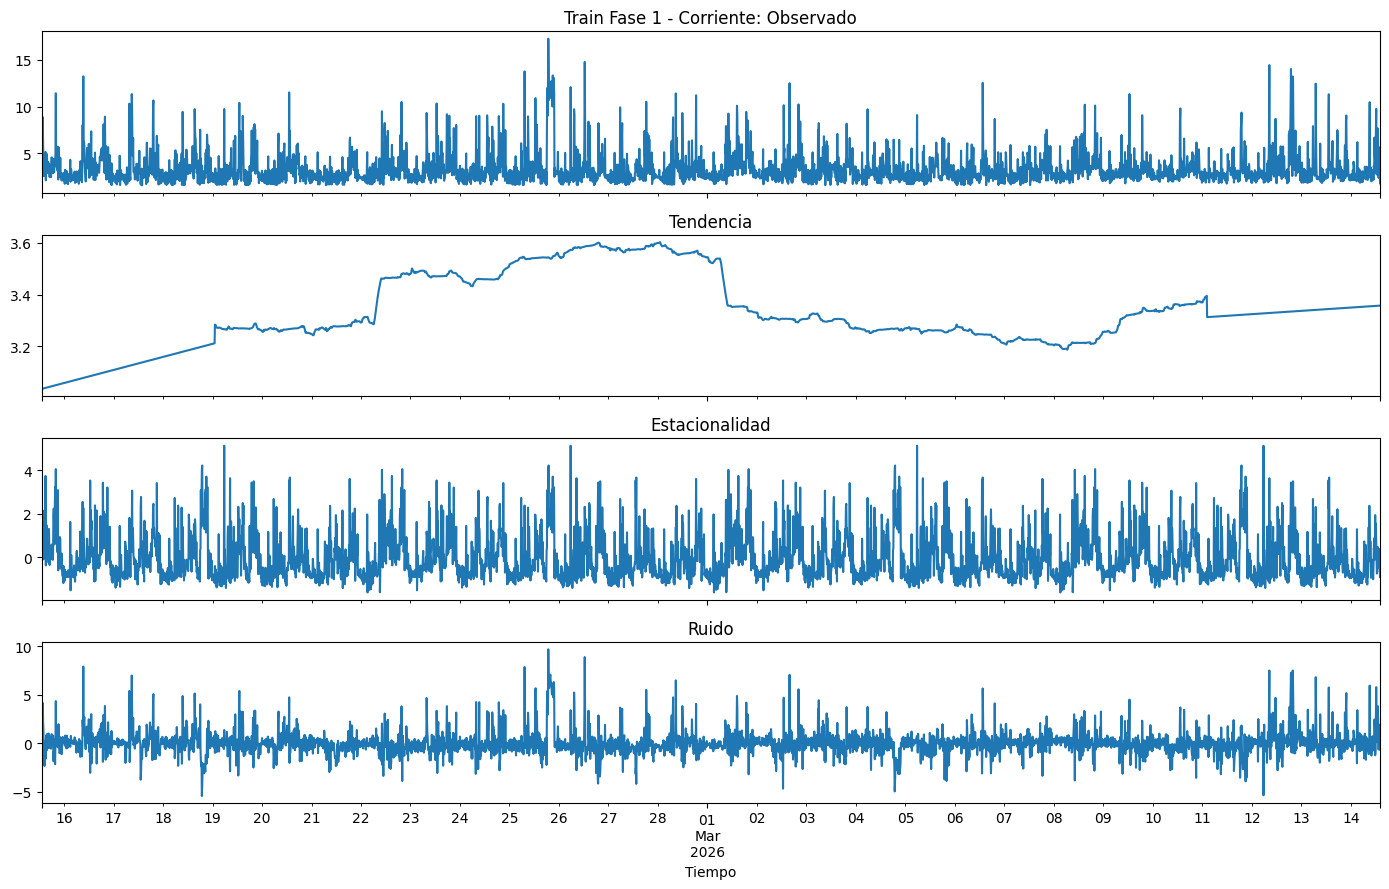

Descomposición completada: Train Fase 1 - Corriente


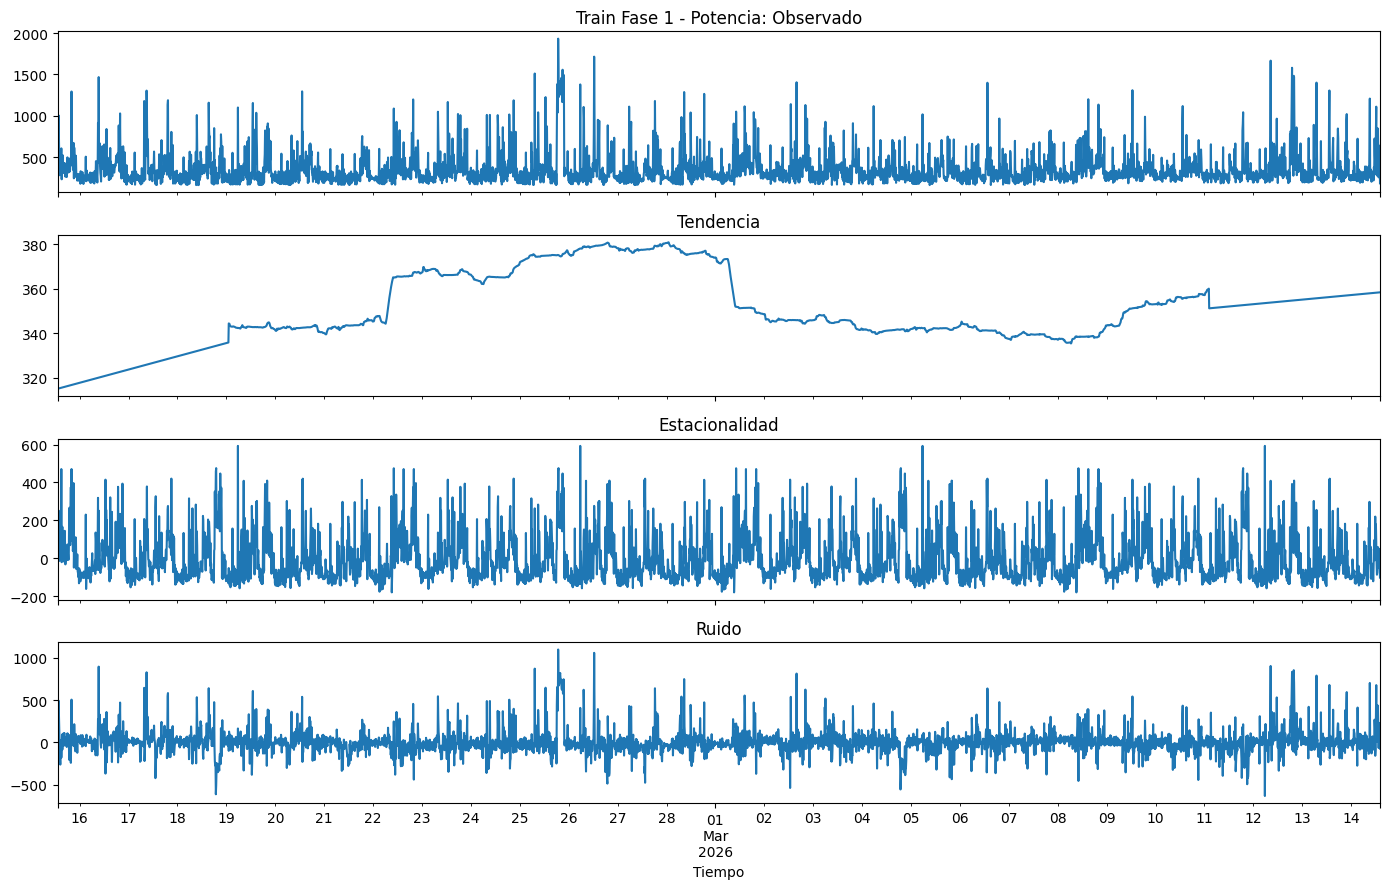

Descomposición completada: Train Fase 1 - Potencia


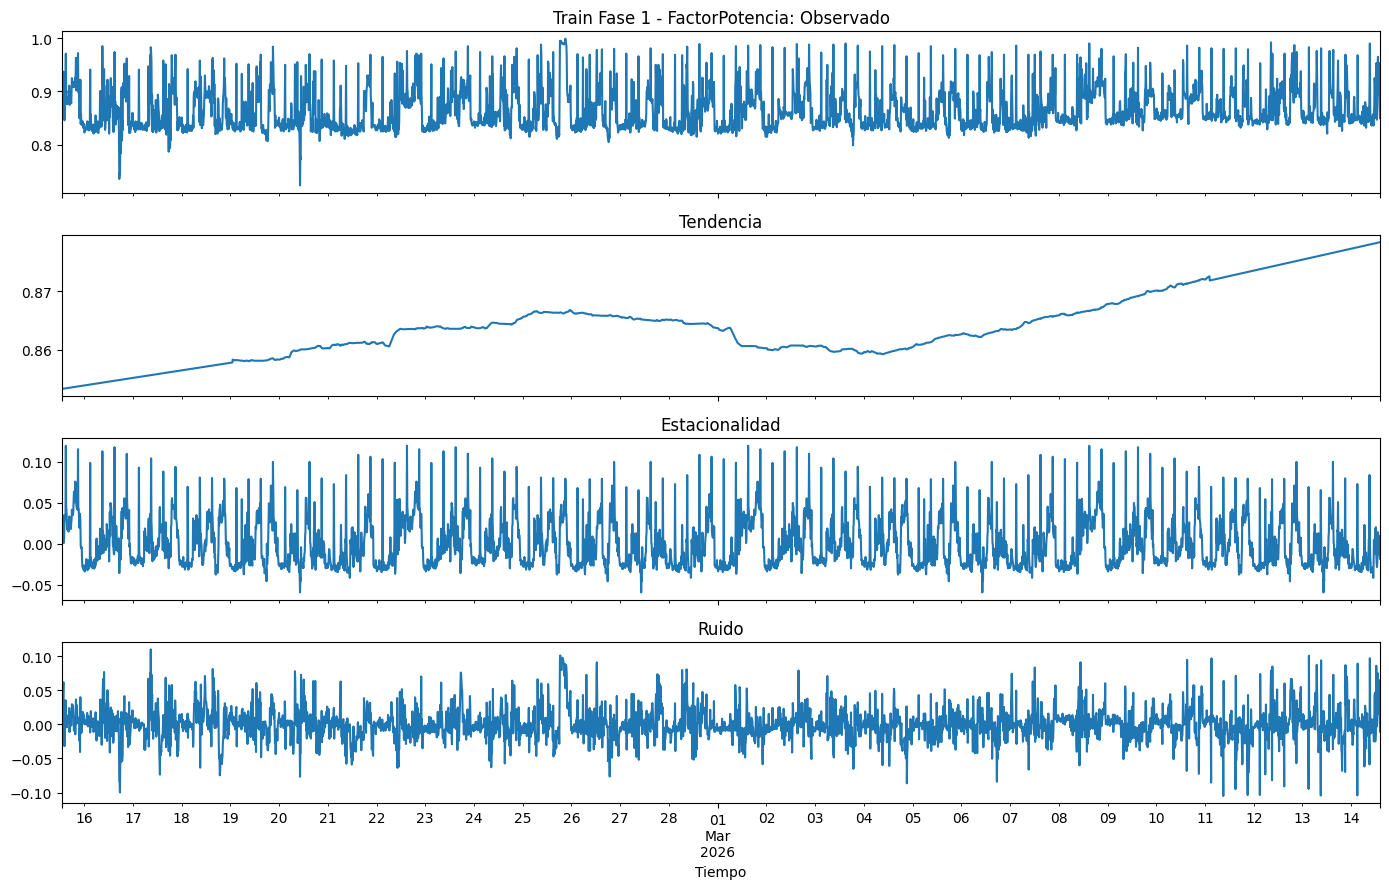

Descomposición completada: Train Fase 1 - FactorPotencia


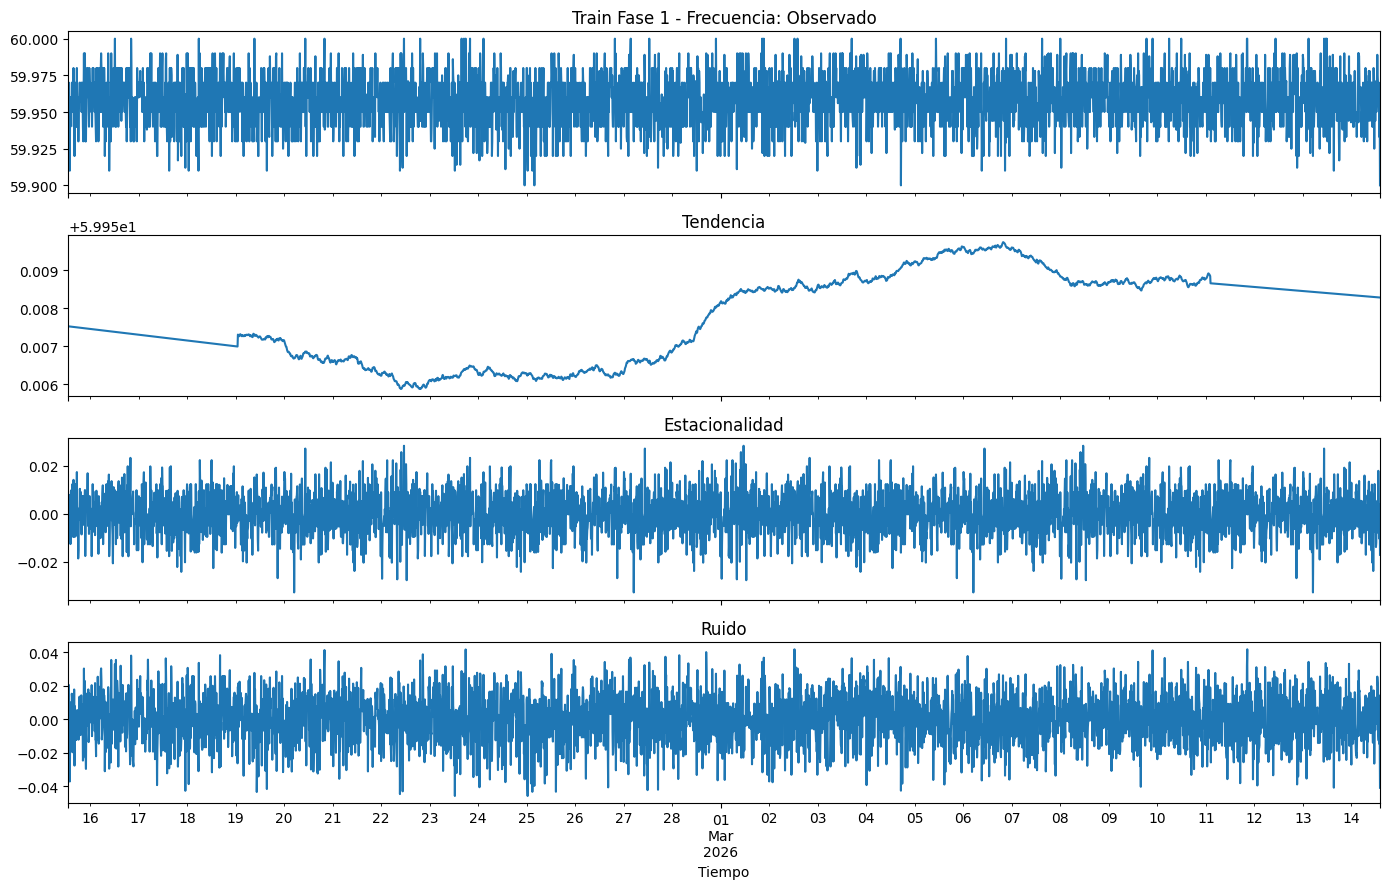

Descomposición completada: Train Fase 1 - Frecuencia
Descomposición de Test - Fase 1


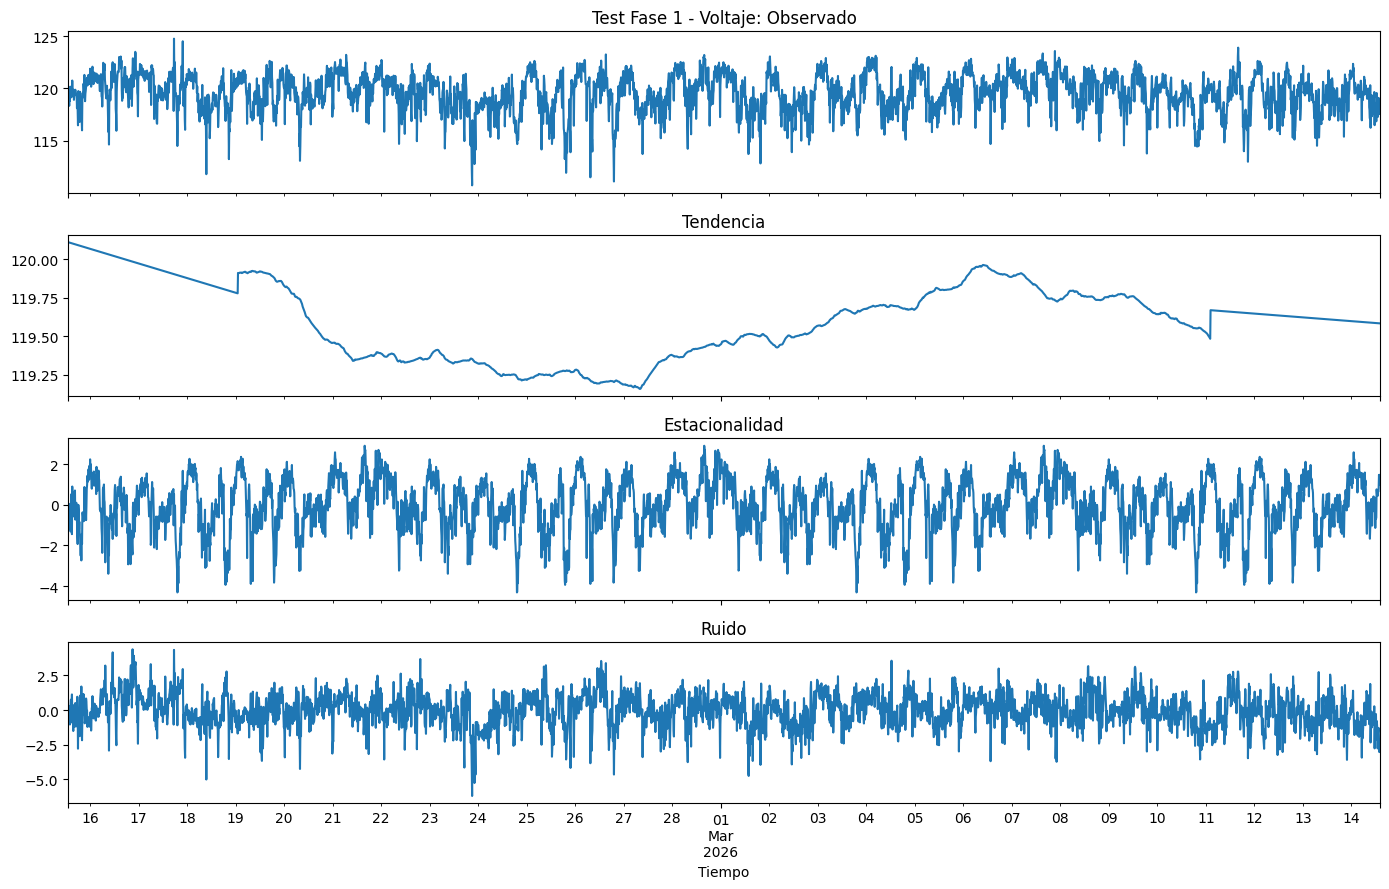

Descomposición completada: Test Fase 1 - Voltaje


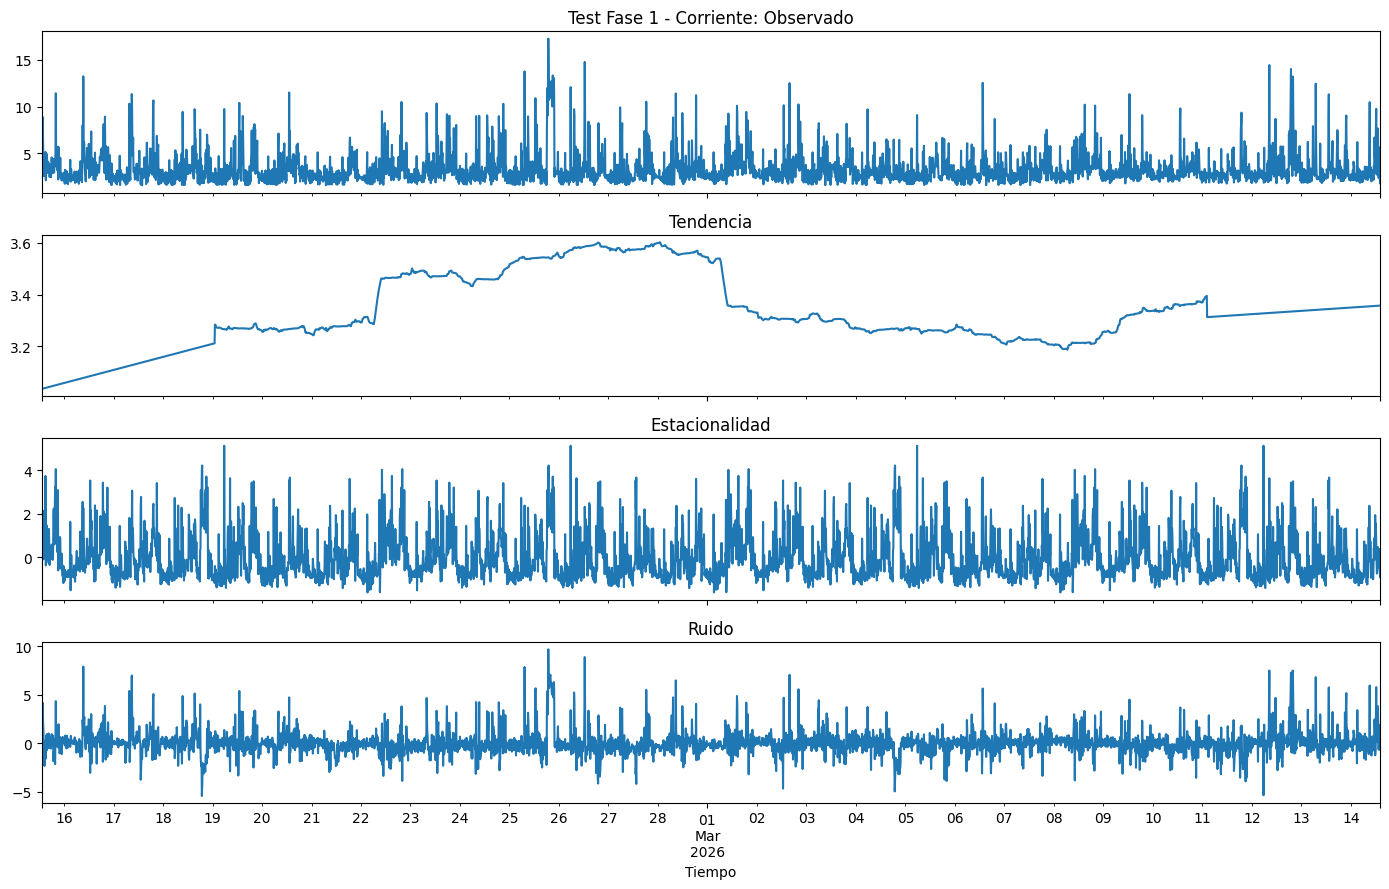

Descomposición completada: Test Fase 1 - Corriente


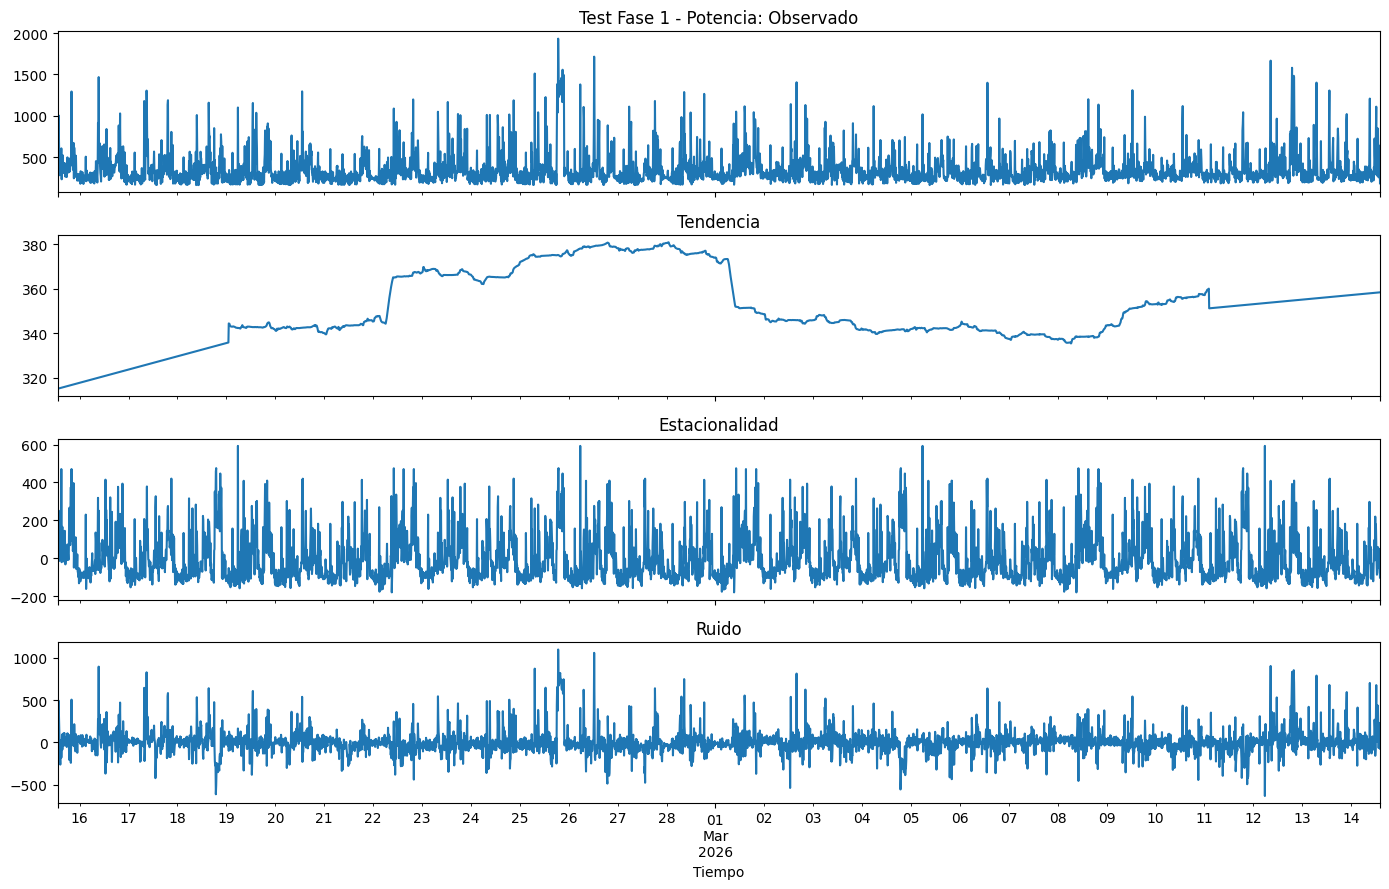

Descomposición completada: Test Fase 1 - Potencia


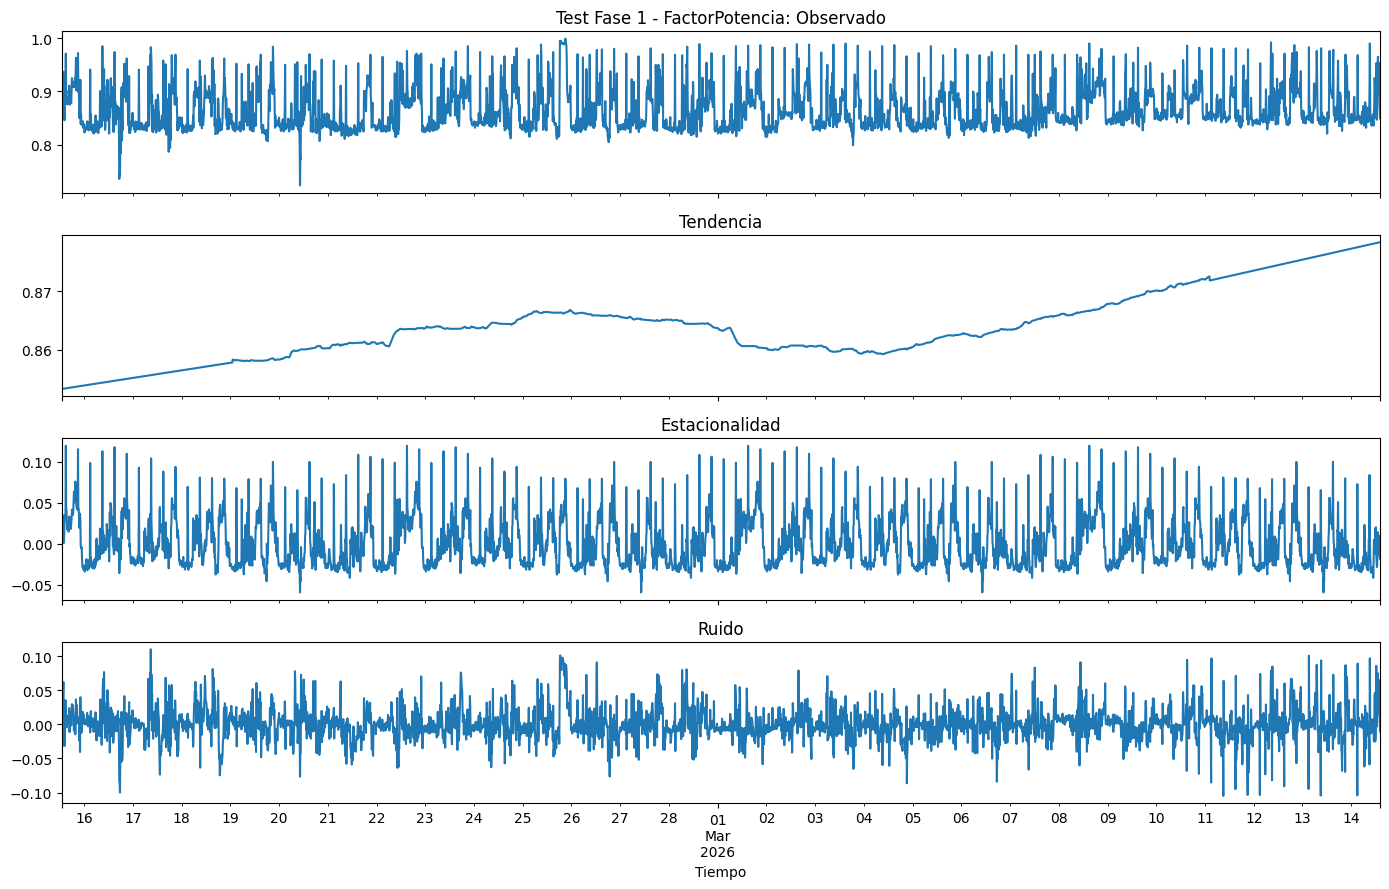

Descomposición completada: Test Fase 1 - FactorPotencia


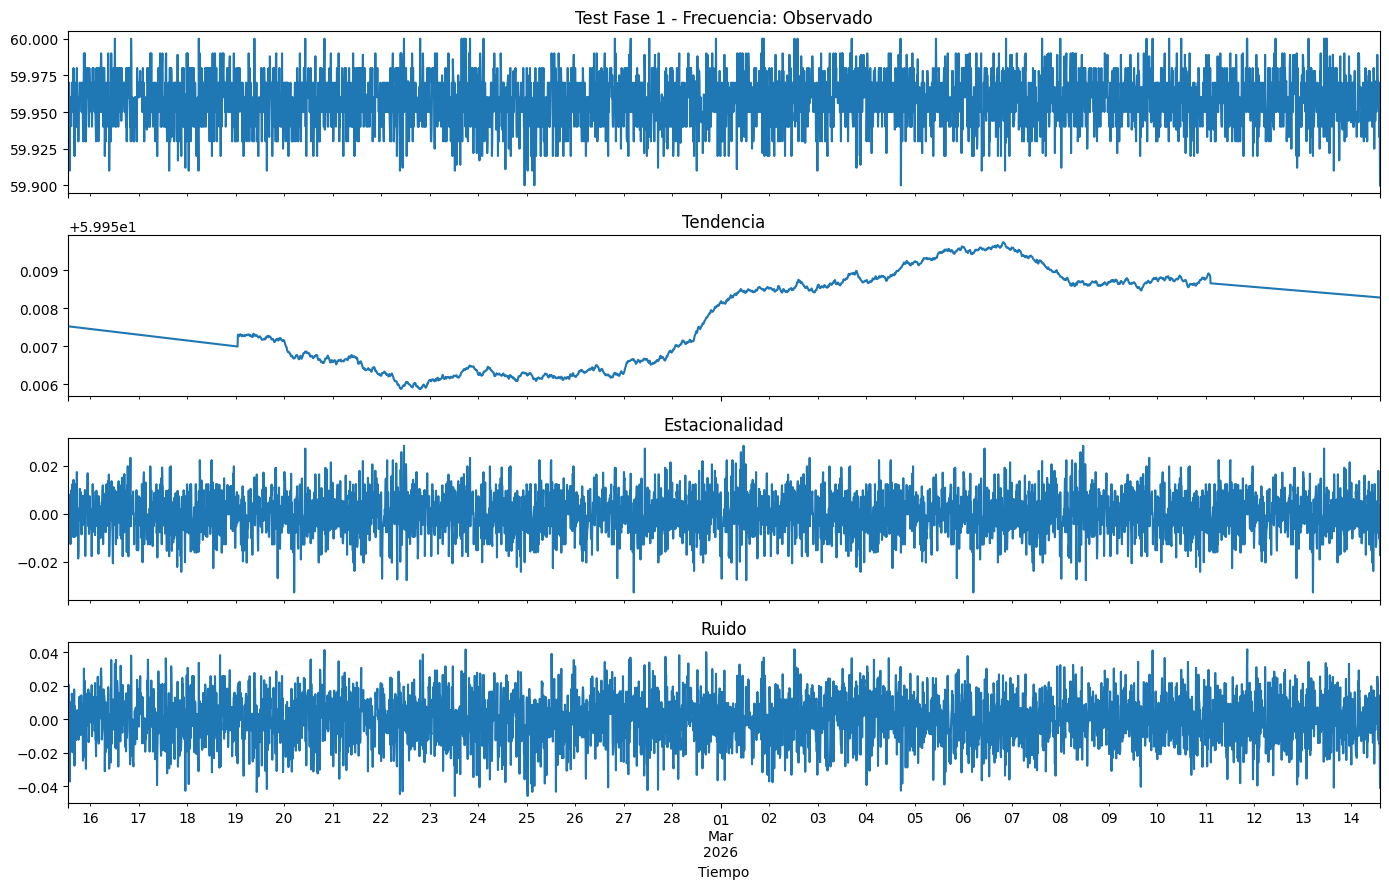

Descomposición completada: Test Fase 1 - Frecuencia
Descomposición de Train - Fase 2


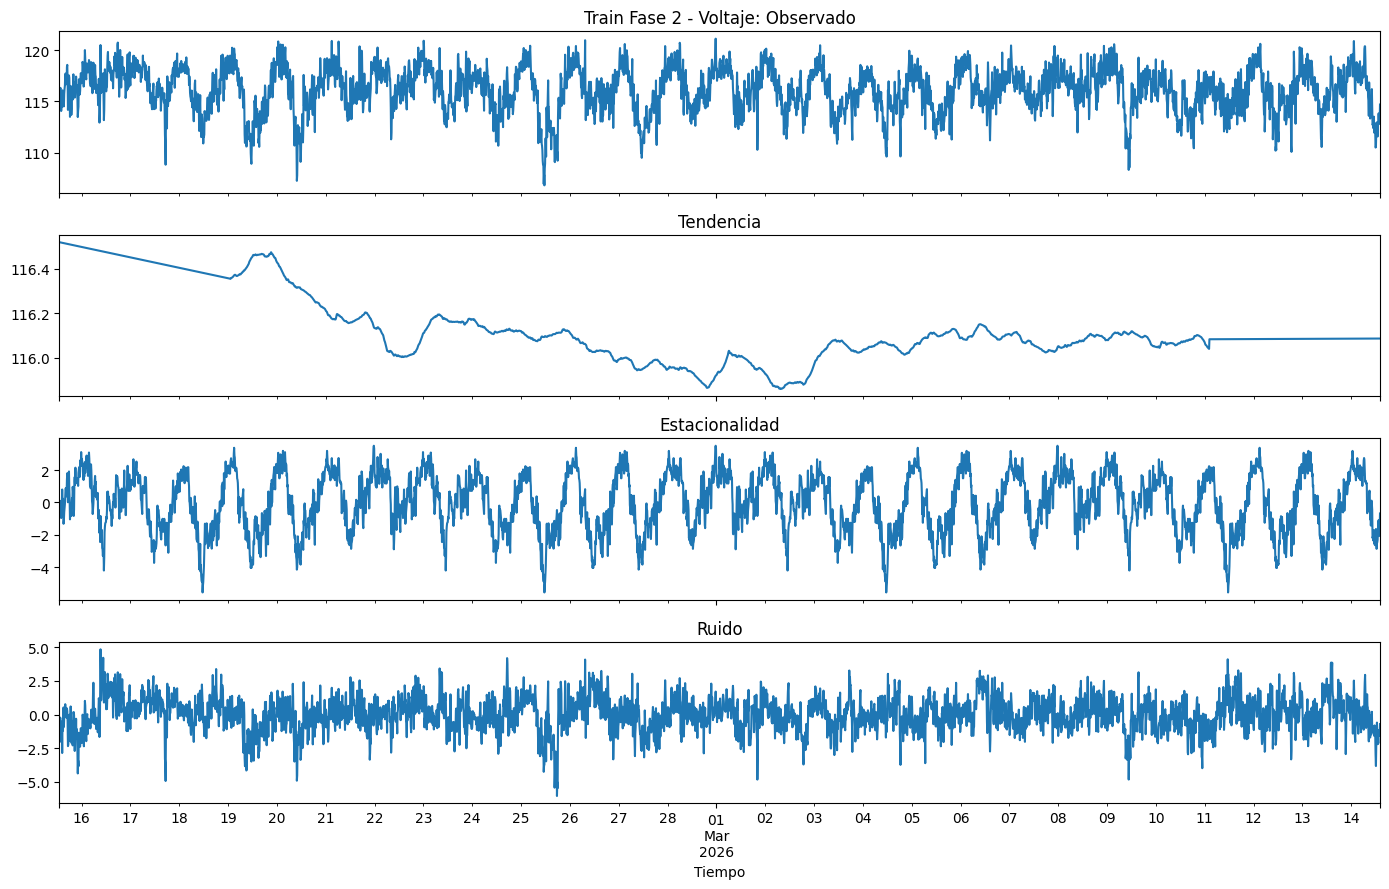

Descomposición completada: Train Fase 2 - Voltaje


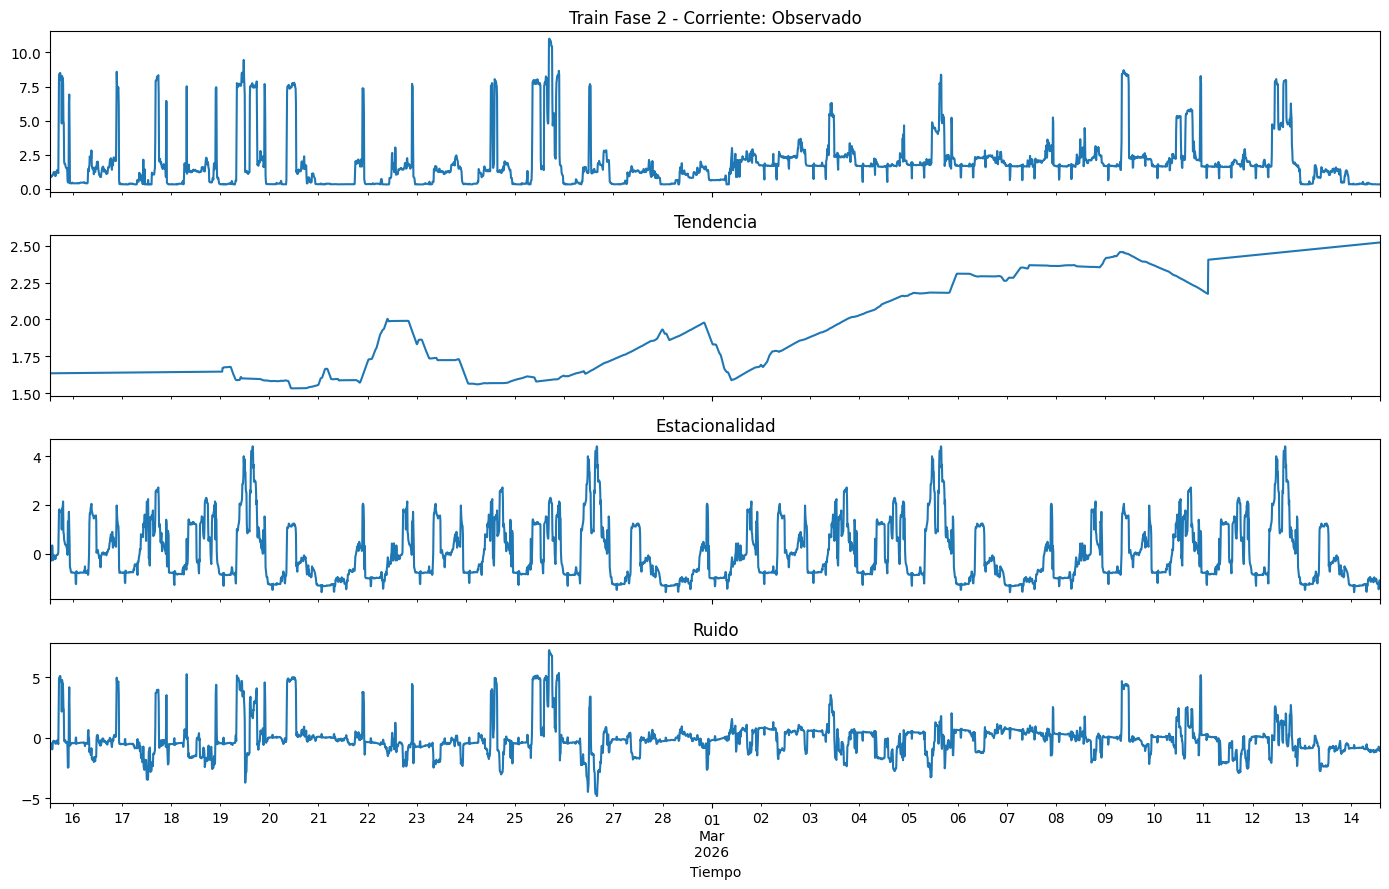

Descomposición completada: Train Fase 2 - Corriente


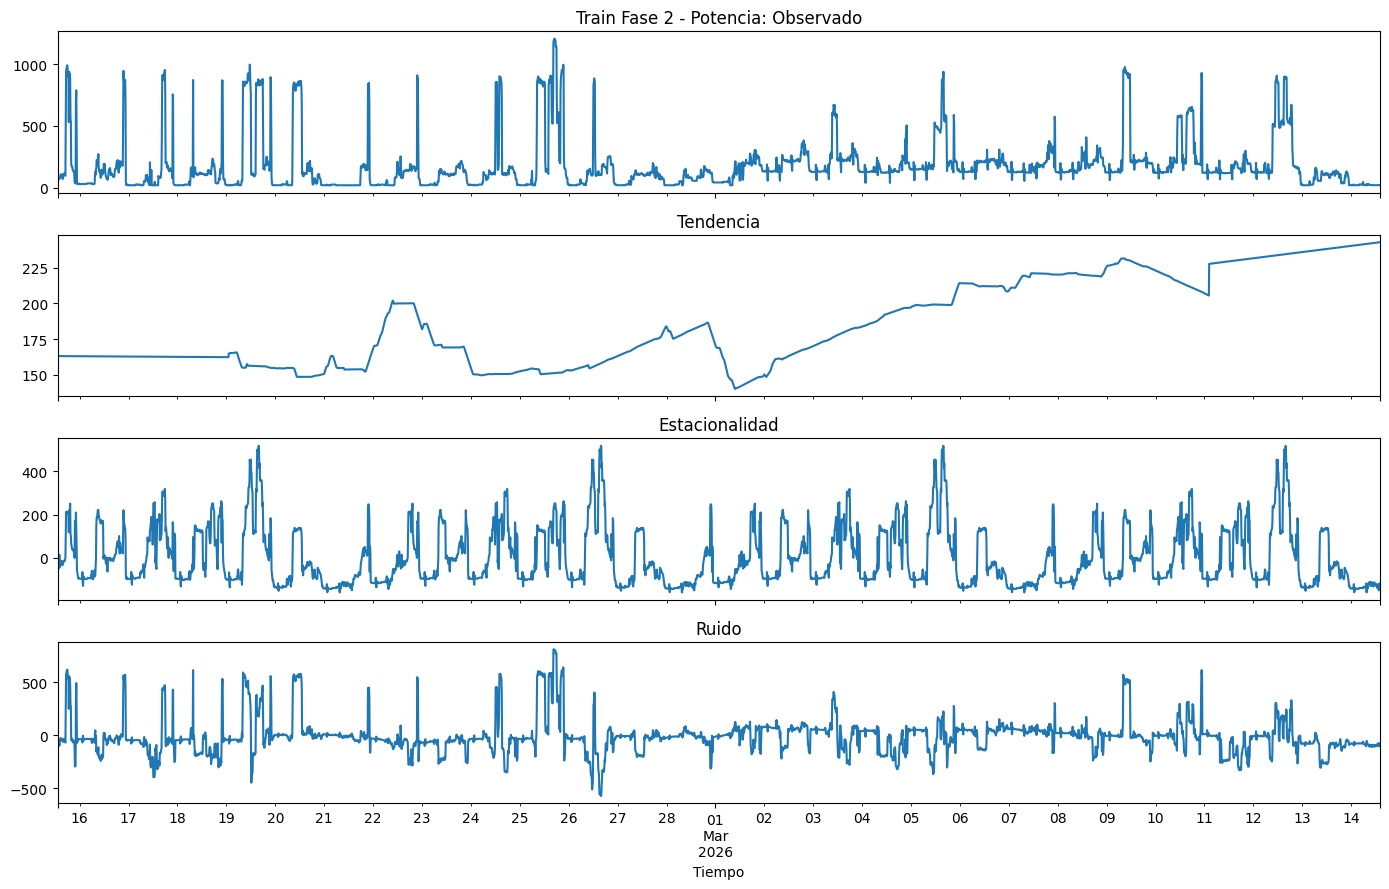

Descomposición completada: Train Fase 2 - Potencia


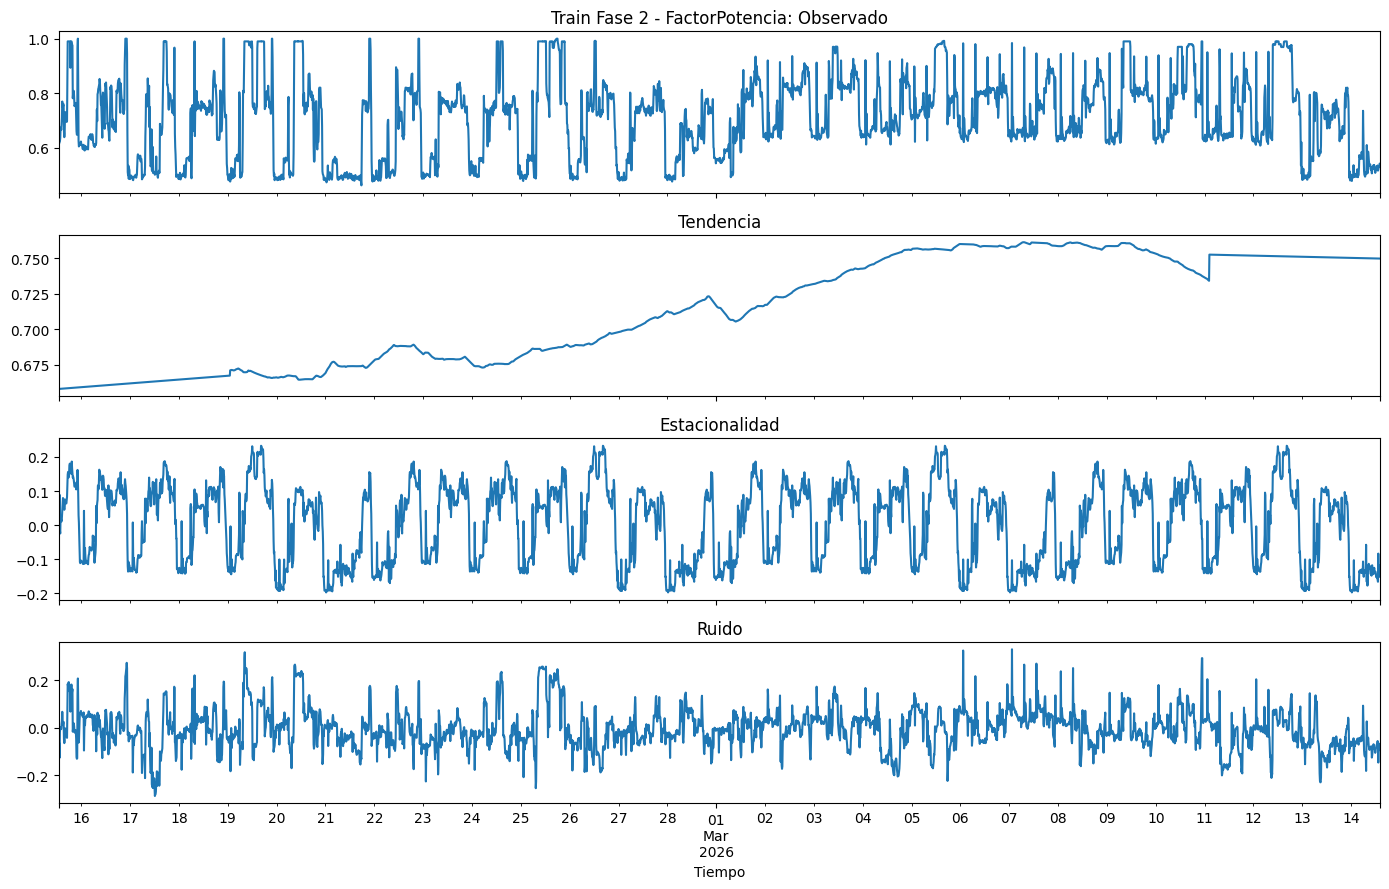

Descomposición completada: Train Fase 2 - FactorPotencia


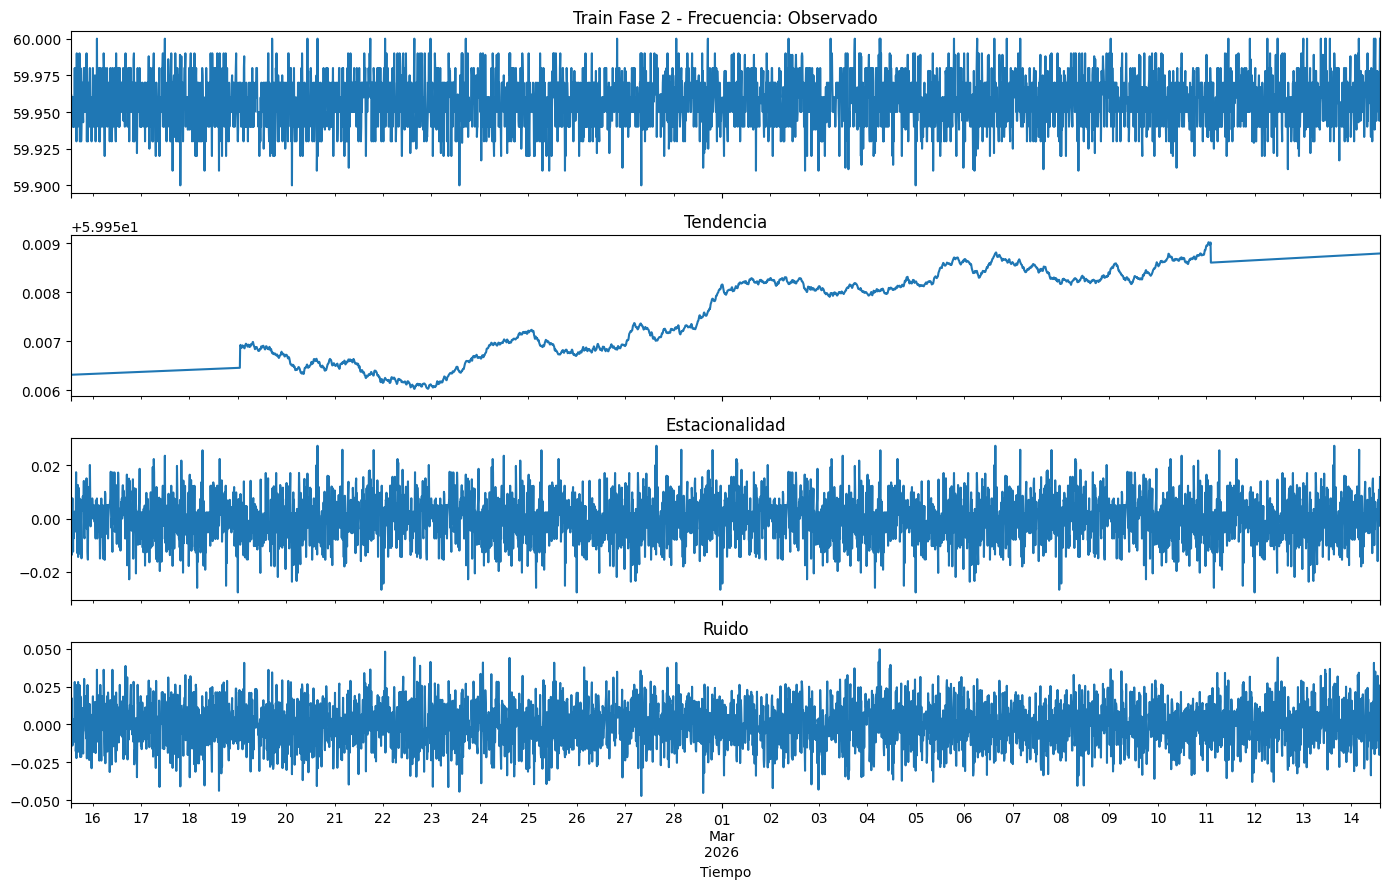

Descomposición completada: Train Fase 2 - Frecuencia
Descomposición de Test - Fase 2


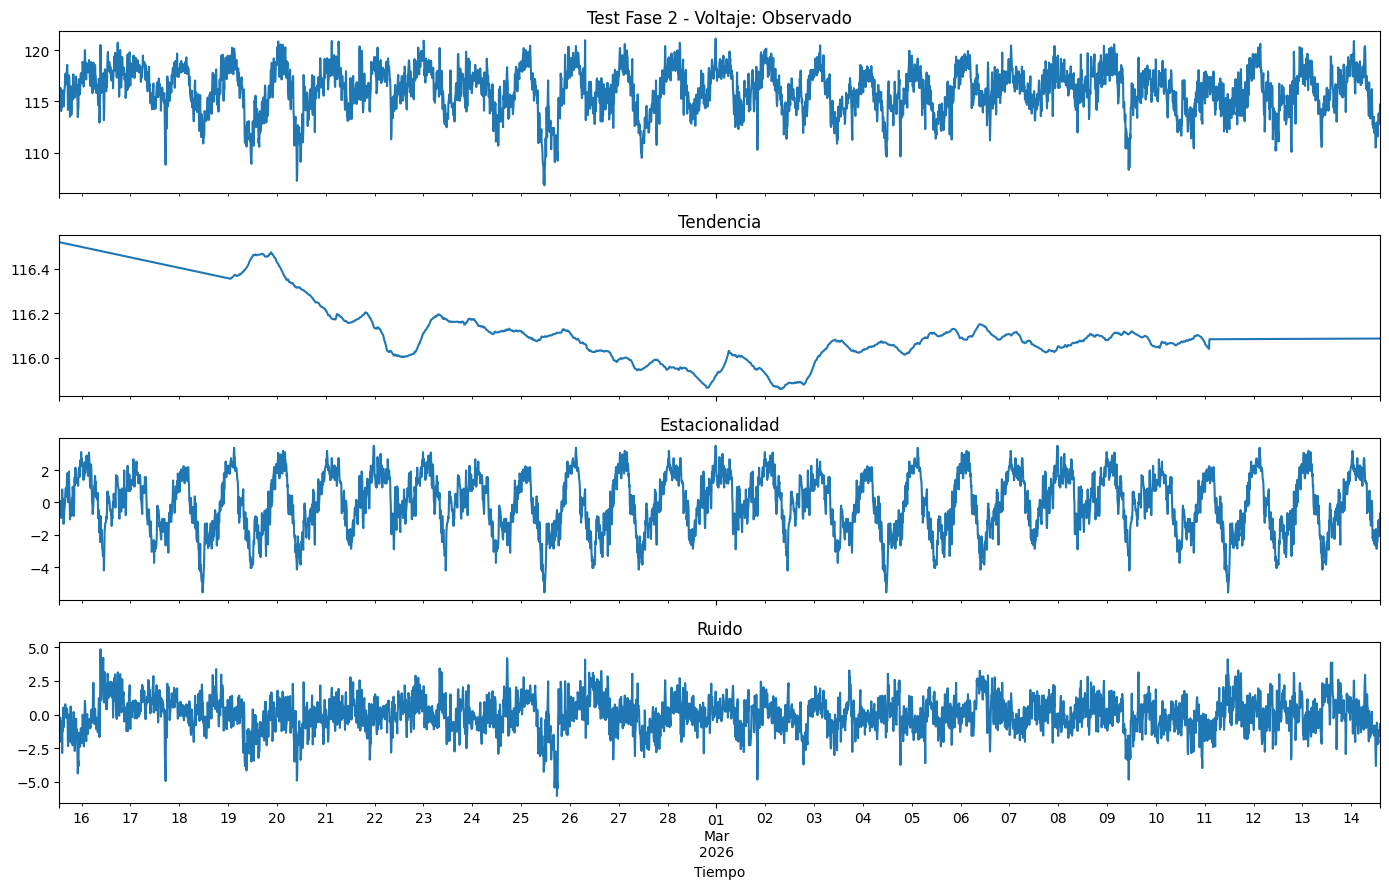

Descomposición completada: Test Fase 2 - Voltaje


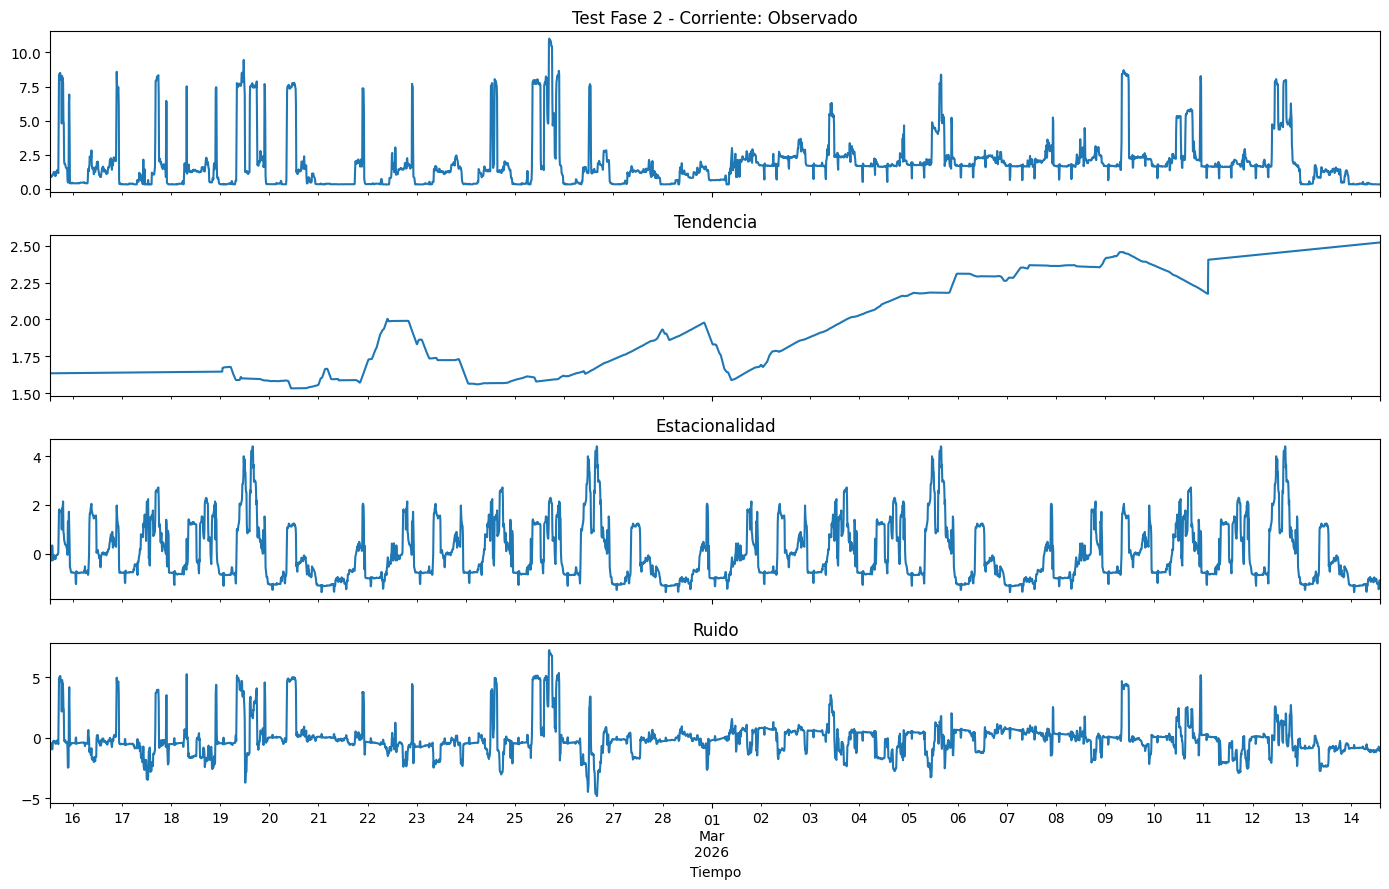

Descomposición completada: Test Fase 2 - Corriente


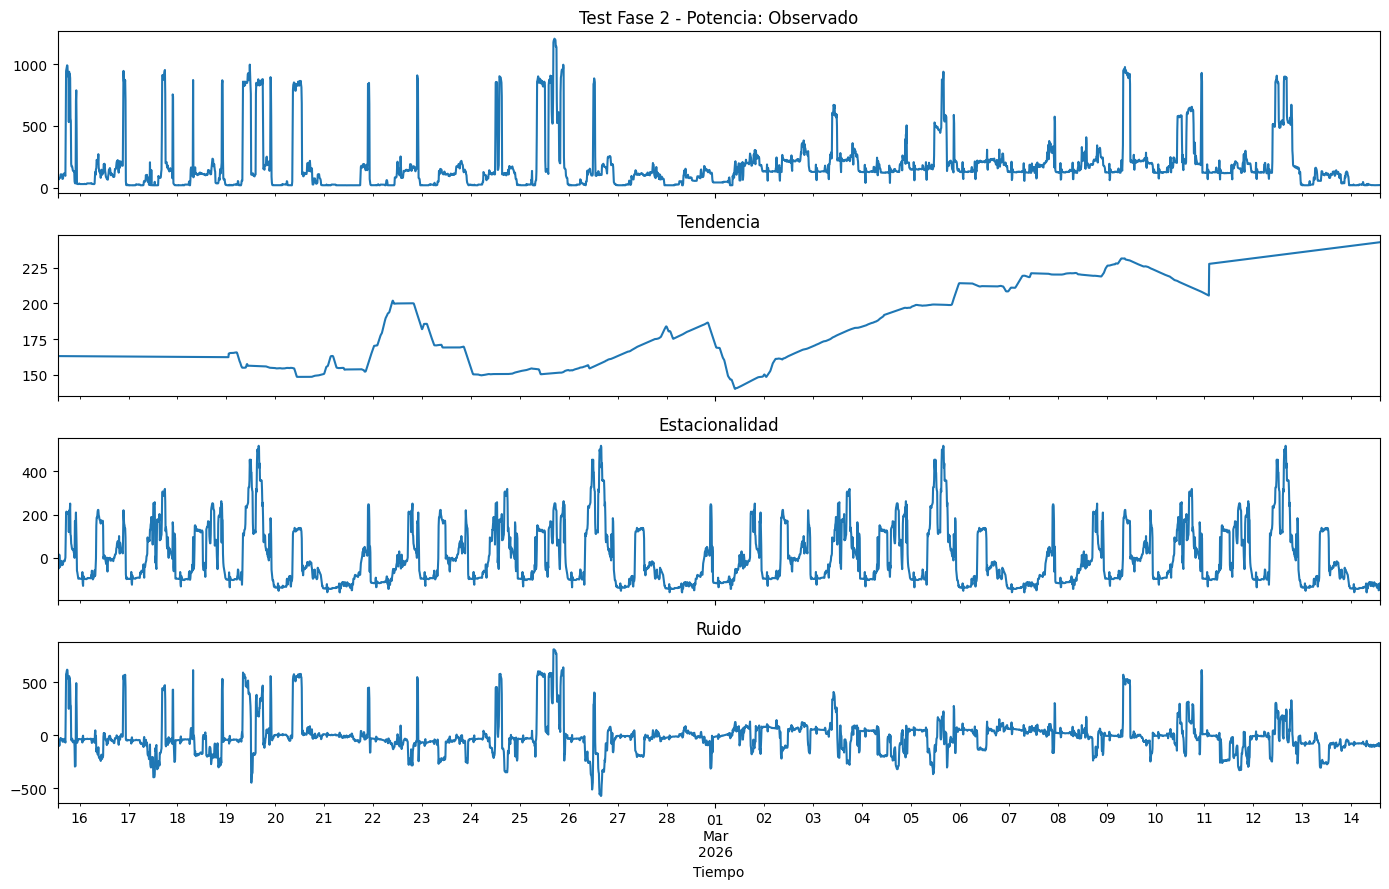

Descomposición completada: Test Fase 2 - Potencia


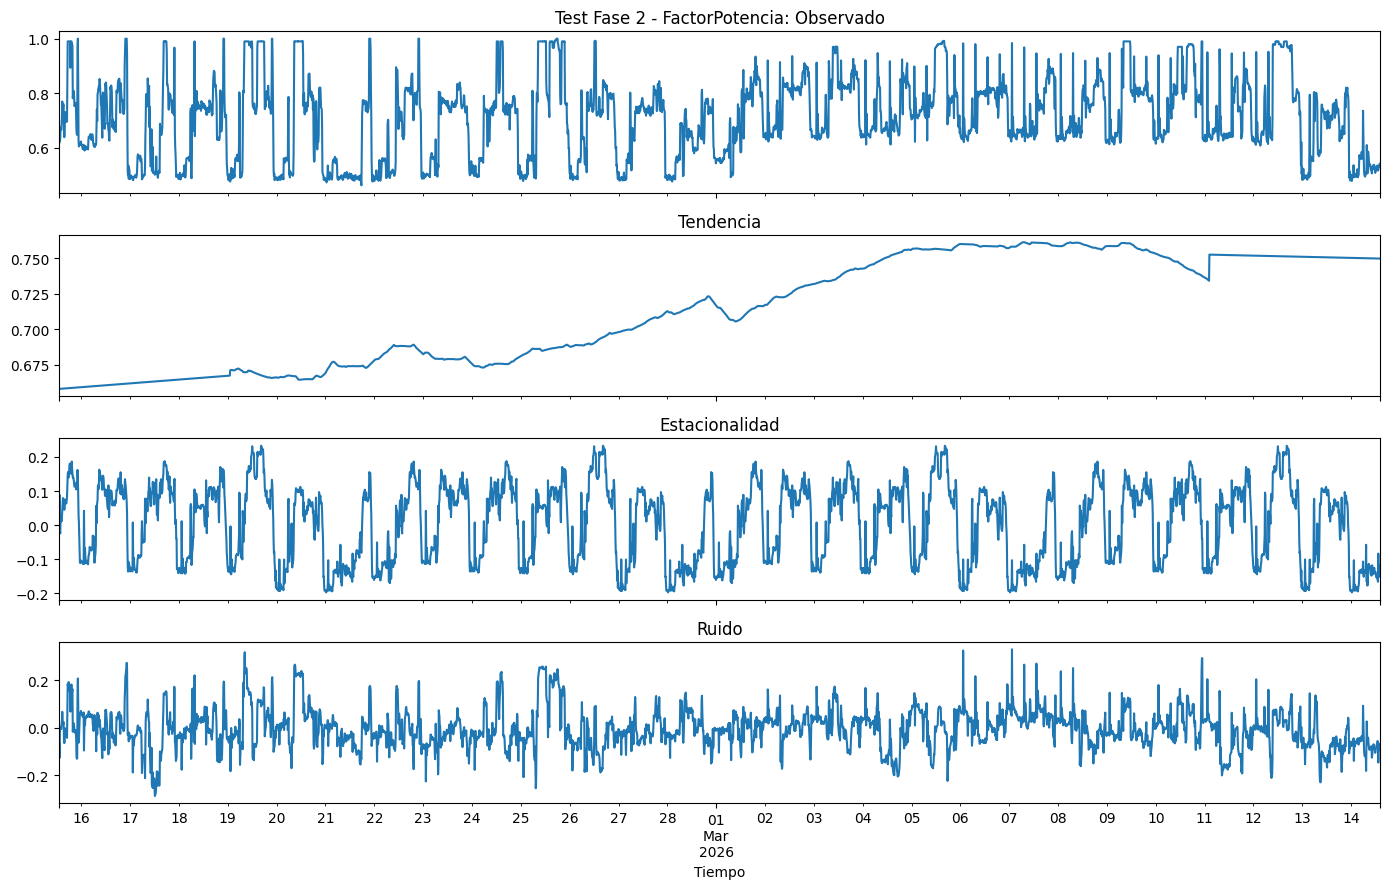

Descomposición completada: Test Fase 2 - FactorPotencia


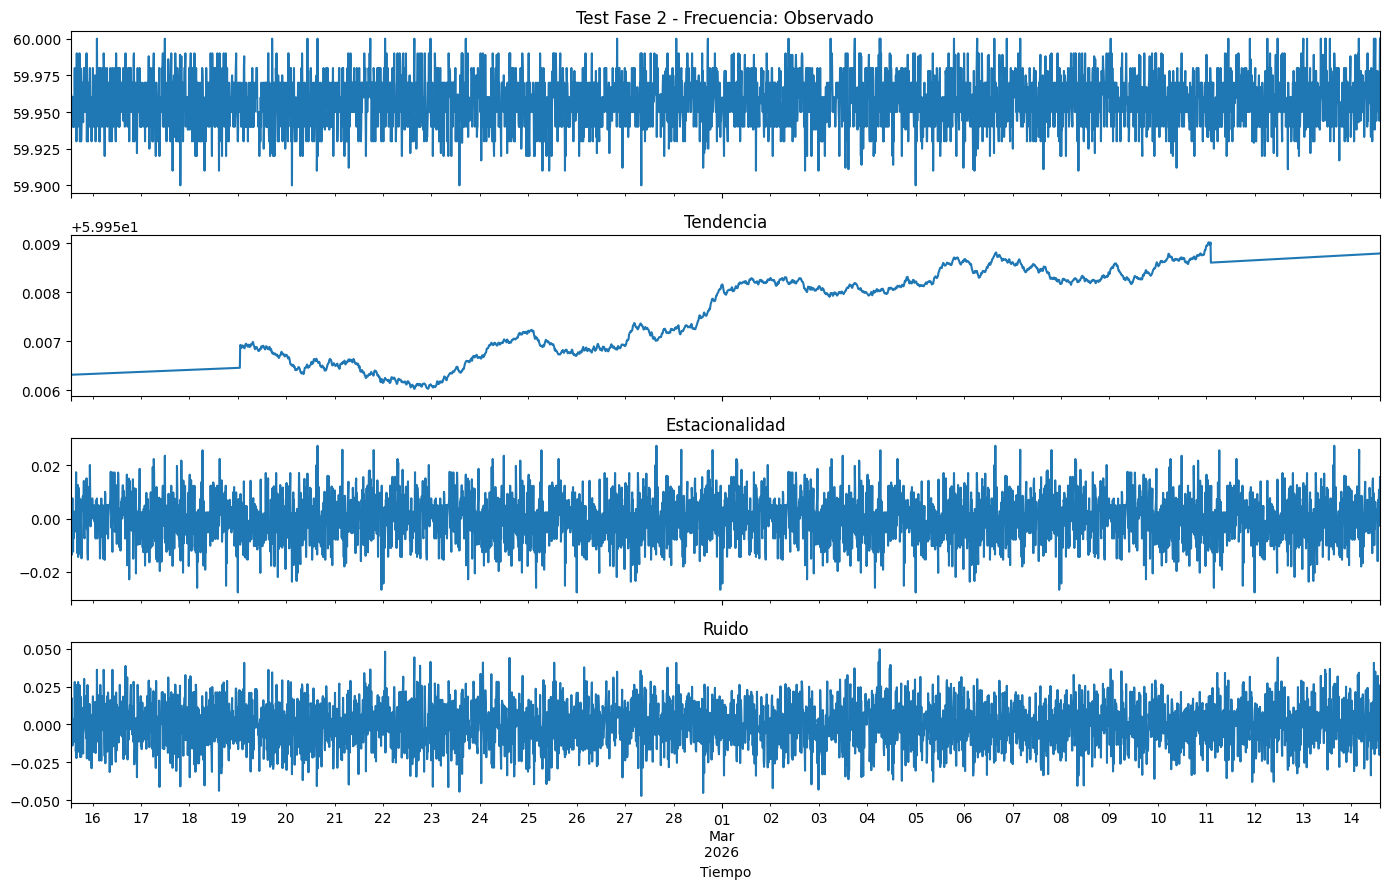

Descomposición completada: Test Fase 2 - Frecuencia


In [ ]:
def descomponer_series(df_serie, nombre_serie, columnas, modelo="additive", periodo=1008):
    columnas_validas = [c for c in columnas if c in df_serie.columns]
    resultados = {}

    for col in columnas_validas:

        serie = df_serie[[col]].copy()
        resultado = seasonal_decompose(serie, model=modelo, period=periodo, extrapolate_trend="freq")
        componentes = pd.DataFrame({"observado": resultado.observed, "tendencia": resultado.trend, "estacionalidad": resultado.seasonal, "ruido": resultado.resid})
        resultados[col] = componentes
        fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)
        componentes["observado"].plot(ax=axes[0], title=f"{nombre_serie} - {col}: Observado")
        componentes["tendencia"].plot(ax=axes[1], title="Tendencia")
        componentes["estacionalidad"].plot(ax=axes[2], title="Estacionalidad")
        componentes["ruido"].plot(ax=axes[3], title="Ruido")

        axes[3].set_xlabel("Tiempo")
        plt.tight_layout()
        plt.show()

        print(f"Descomposición completada: {nombre_serie} - {col}")

    return resultados

def preparar_ts_por_fase(df_entrada, fase):
    data = df_entrada.copy()
    data["FechaMedicion"] = pd.to_datetime(data["FechaMedicion"], errors="coerce")
    data = data.dropna(subset=["FechaMedicion"])
    data = data[data["Fase"] == fase].sort_values("FechaMedicion")
    return data.set_index("FechaMedicion")

for fase in (1, 2):

    print(f"Descomposición de Train - Fase {fase}")
    df_train_ts_fase = preparar_ts_por_fase(df_train, fase)
    componentes_train = descomponer_series(df_train_ts_fase, f"Train Fase {fase}", columnas_graficar)

    print(f"Descomposición de Test - Fase {fase}")
    df_test_ts_fase = preparar_ts_por_fase(df_test, fase)
    componentes_test = descomponer_series(df_test_ts_fase, f"Test Fase {fase}", columnas_graficar)


### Correlación entre variables

Matriz de correlación (pearson) - Train - Fase 1


,Voltaje,Corriente,Potencia,FactorPotencia,Frecuencia
Voltaje,1.000,-0.463,-0.446,-0.443,-0.021
Corriente,-0.463,1.000,0.998,0.742,0.025
Potencia,-0.446,0.998,1.000,0.774,0.025
FactorPotencia,-0.443,0.742,0.774,1.000,0.030
Frecuencia,-0.021,0.025,0.025,0.030,1.000


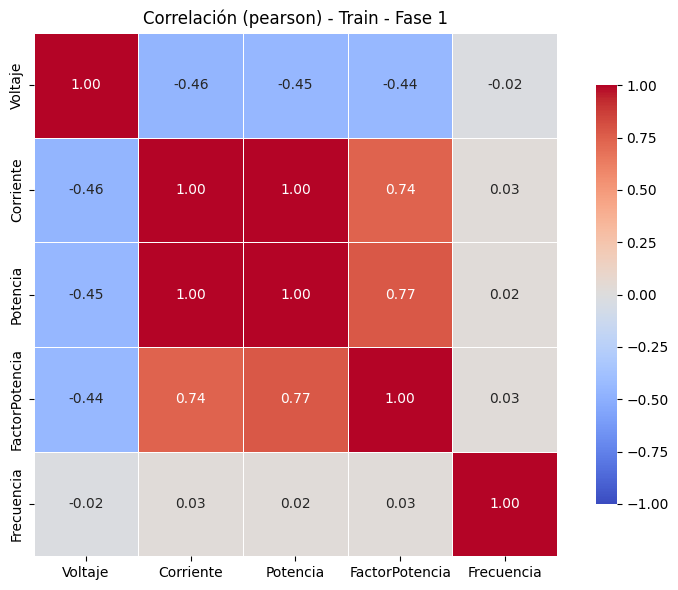

Matriz de correlación (pearson) - Train - Fase 2


,Voltaje,Corriente,Potencia,FactorPotencia,Frecuencia
Voltaje,1.000,-0.524,-0.512,-0.522,-0.023
Corriente,-0.524,1.000,0.996,0.803,-0.013
Potencia,-0.512,0.996,1.000,0.796,-0.015
FactorPotencia,-0.522,0.803,0.796,1.000,0.008
Frecuencia,-0.023,-0.013,-0.015,0.008,1.000


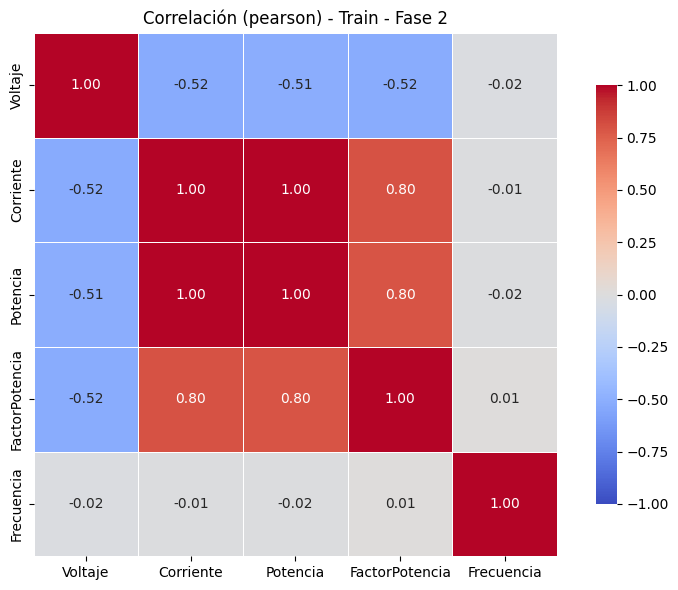

Matriz de correlación (pearson) - Test - Fase 1


,Voltaje,Corriente,Potencia,FactorPotencia,Frecuencia
Voltaje,1.000,-0.463,-0.446,-0.443,-0.021
Corriente,-0.463,1.000,0.998,0.742,0.025
Potencia,-0.446,0.998,1.000,0.774,0.025
FactorPotencia,-0.443,0.742,0.774,1.000,0.030
Frecuencia,-0.021,0.025,0.025,0.030,1.000


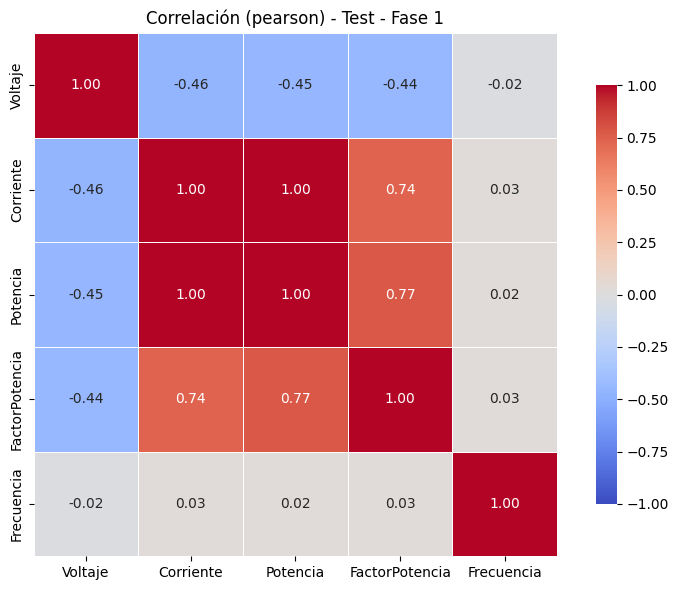

Matriz de correlación (pearson) - Test - Fase 2


,Voltaje,Corriente,Potencia,FactorPotencia,Frecuencia
Voltaje,1.000,-0.524,-0.512,-0.522,-0.023
Corriente,-0.524,1.000,0.996,0.803,-0.013
Potencia,-0.512,0.996,1.000,0.796,-0.015
FactorPotencia,-0.522,0.803,0.796,1.000,0.008
Frecuencia,-0.023,-0.013,-0.015,0.008,1.000


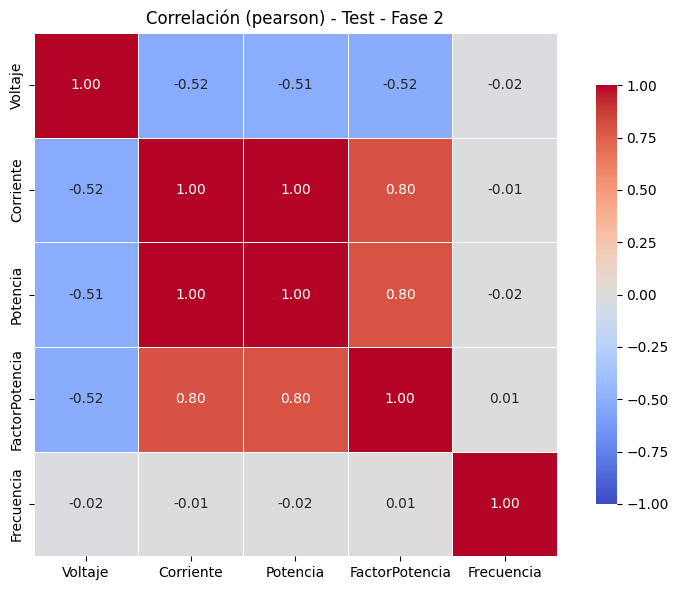

In [11]:
def calcular_y_graficar_correlacion(df_serie, nombre_serie, columnas, metodo="pearson"):

    columnas_validas = [c for c in columnas if c in df_serie.columns]
    data = df_serie[columnas_validas].apply(pd.to_numeric, errors="coerce")
    matriz_corr = data.corr(method=metodo)
    print(f"Matriz de correlación ({metodo}) - {nombre_serie}")
    display(matriz_corr.round(3))
    plt.figure(figsize=(8, 6))

    sns.heatmap(
        matriz_corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8},

    )

    plt.title(f"Correlación ({metodo}) - {nombre_serie}")
    plt.tight_layout()
    plt.show()

    return matriz_corr



def calcular_correlacion_por_fase(df_entrada, nombre_base, columnas, fases=(1, 2), metodo="pearson"):

    if "Fase" not in df_entrada.columns:
        print(f"No se encontró la columna 'Fase' en {nombre_base}.")

        return {}

    resultados = {}

    for fase in fases:

        df_fase = df_entrada[df_entrada["Fase"] == fase]
        if df_fase.empty:
            print(f"Sin datos para {nombre_base} - Fase {fase}")
            continue

        nombre_serie = f"{nombre_base} - Fase {fase}"
        resultados[fase] = calcular_y_graficar_correlacion(df_fase, nombre_serie, columnas, metodo=metodo)

    return resultados



corr_train_por_fase = calcular_correlacion_por_fase(df_train, "Train", columnas_graficar)
corr_test_por_fase = calcular_correlacion_por_fase(df_test, "Test", columnas_graficar)
